# Money Matrix — Algorithmic Trading Strategy

**Strategy:** Adaptive Trend-Momentum System using MACD, RSI, and Supertrend    
**Capital:** $1,000,000 | **Benchmark:** Equal-Weight Buy & Hold


## Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import seaborn as sns
import warnings
from datetime import datetime, timedelta
from itertools import product
from scipy import stats
import os

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:,.4f}".format)

In [2]:
# ── Plot Styling 
plt.style.use("dark_background")
plt.rcParams.update({
    "figure.figsize": (16, 8),
    "font.family": "sans-serif",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "figure.dpi": 120,
    "savefig.dpi": 150,
    "axes.grid": True,
    "grid.alpha": 0.12,
    "grid.linestyle": "--",
    "axes.facecolor": "#0d1117",
    "figure.facecolor": "#0d1117",
    "savefig.facecolor": "#0d1117",
})

# ── Colour Palette 
C = {
    "cyan":    "#00d4ff",
    "orange":  "#ff8c00",
    "green":   "#00ff88",
    "red":     "#ff4466",
    "yellow":  "#ffd700",
    "purple":  "#b388ff",
    "pink":    "#ff66b2",
    "white":   "#e6edf3",
    "gray":    "#8b949e",
    "bg":      "#0d1117",
}
STOCK_COLORS = [C["cyan"], C["green"], C["yellow"], C["orange"], C["purple"],
                C["pink"], "#66ccff", "#ff6666", "#66ff66", "#ffaa00"]

In [3]:
# ── Configuration 
TICKERS = ["AAPL", "MSFT", "NVDA", "JPM", "GS",
           "CAT",  "XOM",  "PG",   "JNJ", "PFE"]
SECTOR_MAP = {
    "AAPL": "Technology", "MSFT": "Technology", "NVDA": "Technology",
    "JPM":  "Financials", "GS":   "Financials",
    "CAT":  "Industrials","XOM":  "Energy",
    "PG":   "Consumer",   "JNJ":  "Healthcare", "PFE": "Healthcare",
}

END_DATE   = datetime.now().strftime("%Y-%m-%d")
START_DATE = (datetime.now() - timedelta(days=7 * 365 + 120)).strftime("%Y-%m-%d")

INITIAL_CAPITAL  = 1_000_000
TRANSACTION_BPS  = 10          # basis points
TRANSACTION_COST = TRANSACTION_BPS / 10_000   # 0.0010

TRAIN_YEARS = 5
TEST_YEARS  = 2
RISK_FREE   = 0.04            # annualised risk-free rate (approx T-bill)

# Default indicator parameters
P = dict(
    macd_fast=12, macd_slow=26, macd_signal=9,
    rsi_period=14, rsi_oversold=35, rsi_overbought=80,
    st_period=10, st_mult=2.5,
    bb_period=20, bb_std=2.0,
    stoch_k=14, stoch_d=3,
    wr_period=14, atr_period=14, aroon_period=25,
    sma_short=20, sma_mid=50, sma_long=200,
)

# Output directory for plots
OUT = os.getcwd()

def _save(fig, name):
    fig.savefig(os.path.join(OUT, name), bbox_inches="tight", facecolor=C["bg"])

print("  ALGORITHMIC TRADING STRATEGY — ADAPTIVE TREND-MOMENTUM SYSTEM")
print(f"  Universe : {', '.join(TICKERS)}")
print(f"  Period   : {START_DATE}  →  {END_DATE}")
print(f"  Capital  : ${INITIAL_CAPITAL:,.0f}   |   Cost : {TRANSACTION_BPS} bps")

  ALGORITHMIC TRADING STRATEGY — ADAPTIVE TREND-MOMENTUM SYSTEM
  Universe : AAPL, MSFT, NVDA, JPM, GS, CAT, XOM, PG, JNJ, PFE
  Period   : 2019-02-01  →  2026-05-30
  Capital  : $1,000,000   |   Cost : 10 bps


## Phase 1 — Data Gathering & Preprocessing
Collect 7 years of daily adjusted close prices and volume for all 10 tickers using `yfinance`. Handle missing values and verify data quality.

In [4]:
print(f"\n→ Downloading daily data for {len(TICKERS)} tickers via yfinance …")

raw = yf.download(TICKERS, start=START_DATE, end=END_DATE, auto_adjust=False)

# Handle both yfinance column formats (flat MultiIndex vs grouped)
try:
    adj_close = raw["Adj Close"][TICKERS].copy()
    volume_df = raw["Volume"][TICKERS].copy()
    high_df   = raw["High"][TICKERS].copy()
    low_df    = raw["Low"][TICKERS].copy()
    close_df  = raw["Close"][TICKERS].copy()
except KeyError:
    # Fallback for different yfinance versions
    adj_close = pd.DataFrame({t: raw[(t, "Adj Close")] for t in TICKERS})
    volume_df = pd.DataFrame({t: raw[(t, "Volume")]    for t in TICKERS})
    high_df   = pd.DataFrame({t: raw[(t, "High")]      for t in TICKERS})
    low_df    = pd.DataFrame({t: raw[(t, "Low")]       for t in TICKERS})
    close_df  = pd.DataFrame({t: raw[(t, "Close")]     for t in TICKERS})

# Flatten any multi-level column index
for df in [adj_close, volume_df, high_df, low_df, close_df]:
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(-1)

print(f"  Raw shape : {adj_close.shape}")
print(f"  Range     : {adj_close.index[0].date()}  →  {adj_close.index[-1].date()}")


→ Downloading daily data for 10 tickers via yfinance …


[*********************100%***********************]  10 of 10 completed

  Raw shape : (1841, 10)
  Range     : 2019-02-01  →  2026-05-29


In [5]:
miss = adj_close.isnull().sum()
print("\n  Missing values per ticker:")
for t in TICKERS:
    pct = miss[t] / len(adj_close) * 100
    tag = "" if miss[t] == 0 else "⚠"
    print(f"    {tag} {t:>4s} : {miss[t]:>4d}  ({pct:.2f}%)")

# Forward-fill, then back-fill residual
for df in [adj_close, volume_df, high_df, low_df, close_df]:
    df.ffill(inplace=True)
    df.bfill(inplace=True)

# Trim warm-up buffer (first ~90 trading days needed for 200-SMA)
WARMUP = 250                       # conservative warm-up for SMA-200
analysis_start = adj_close.index[WARMUP]

daily_ret = adj_close.pct_change().dropna()

print(f"\n  After cleaning : 0 NaNs across all tickers  ✓")
print(f"  Analysis start : {analysis_start.date()}")
print(f"  Total trading days in analysis window : "
      f"{len(adj_close.loc[analysis_start:])}")

# ── Summary Statistics ───────────────────────────────────────────
print("\nAdjusted Close Summary Statistics")
print(adj_close.loc[analysis_start:].describe().round(2).to_string())


  Missing values per ticker:
     AAPL :    0  (0.00%)
     MSFT :    0  (0.00%)
     NVDA :    0  (0.00%)
      JPM :    0  (0.00%)
       GS :    0  (0.00%)
      CAT :    0  (0.00%)
      XOM :    0  (0.00%)
       PG :    0  (0.00%)
      JNJ :    0  (0.00%)
      PFE :    0  (0.00%)

  After cleaning : 0 NaNs across all tickers  ✓
  Analysis start : 2020-01-30
  Total trading days in analysis window : 1591

Adjusted Close Summary Statistics
Ticker       AAPL       MSFT       NVDA        JPM         GS        CAT        XOM         PG        JNJ        PFE
count  1,591.0000 1,591.0000 1,591.0000 1,591.0000 1,591.0000 1,591.0000 1,591.0000 1,591.0000 1,591.0000 1,591.0000
mean     172.3500   323.0100    66.8100   168.4500   411.0300   284.3700    83.8500   136.8500   152.3500    29.3200
std       53.7100    99.6500    64.0400    71.1100   206.8400   161.8100    33.0800    17.9200    25.7100     6.3700
min       54.1600   128.3600     4.8900    66.7600   117.1300    81.3000    23.82

### Plot 1 — Normalised Prices & Total Returns

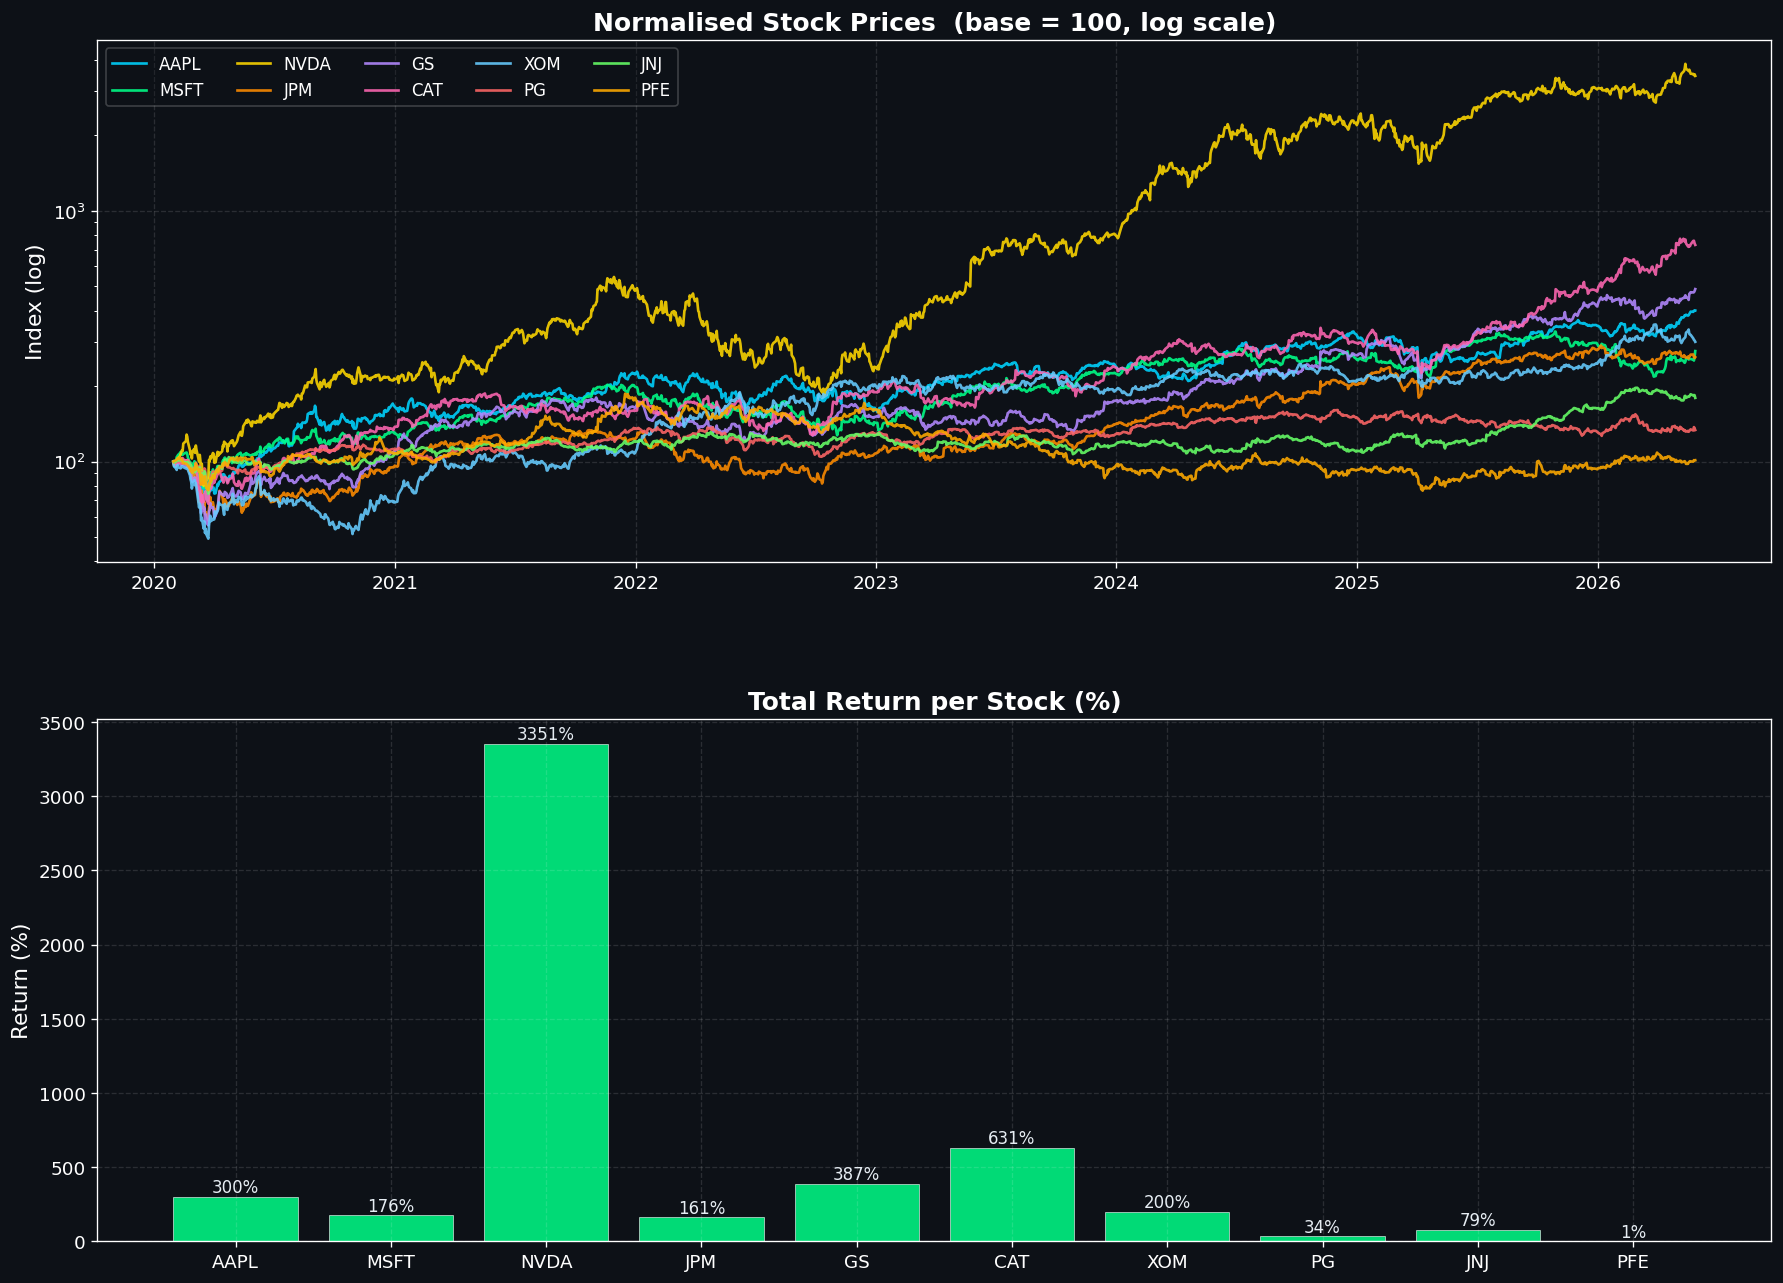

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(18, 13), gridspec_kw={"hspace": 0.30})

norm = adj_close.loc[analysis_start:].div(adj_close.loc[analysis_start:].iloc[0]) * 100
for i, t in enumerate(TICKERS):
    axes[0].plot(norm.index, norm[t], label=t,
                 color=STOCK_COLORS[i], lw=1.6, alpha=0.88)
axes[0].set_yscale("log")
axes[0].set_title("Normalised Stock Prices  (base = 100, log scale)")
axes[0].set_ylabel("Index (log)")
axes[0].legend(ncol=5, loc="upper left", framealpha=0.25)

# Cumulative returns bar chart (total period)
total_ret = (adj_close.loc[analysis_start:].iloc[-1]
             / adj_close.loc[analysis_start:].iloc[0] - 1) * 100
colours = [C["green"] if r > 0 else C["red"] for r in total_ret]
bars = axes[1].bar(TICKERS, total_ret, color=colours, alpha=0.85,
                   edgecolor="white", linewidth=0.4)
for bar, r in zip(bars, total_ret):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 3, f"{r:.0f}%",
                 ha="center", va="bottom", fontsize=10, color=C["white"])
axes[1].set_title("Total Return per Stock (%)")
axes[1].set_ylabel("Return (%)")
axes[1].axhline(0, color=C["gray"], lw=0.5)
_save(fig, "01_stock_prices.png")
plt.show()

### Plot 2 — Volume & Correlation

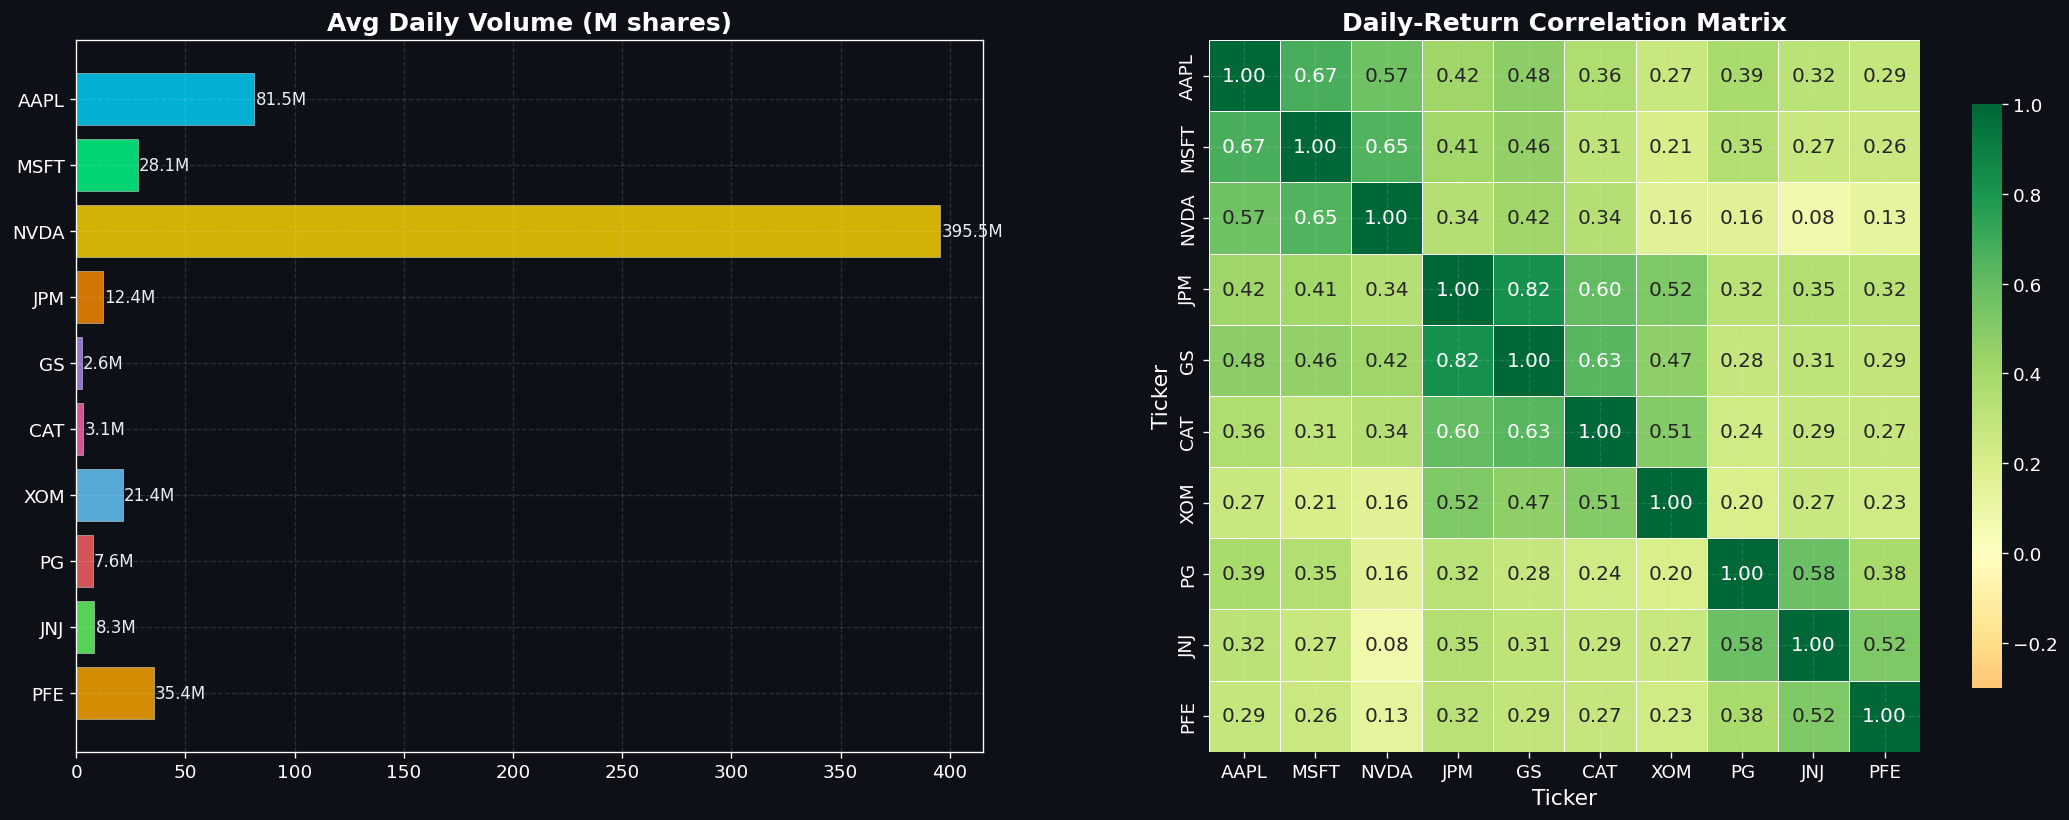

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7),
                         gridspec_kw={"width_ratios": [1, 1.15]})

avg_vol = volume_df.loc[analysis_start:].mean() / 1e6
axes[0].barh(TICKERS[::-1], avg_vol[TICKERS[::-1]],
             color=STOCK_COLORS[::-1], alpha=0.82, edgecolor="white", lw=0.3)
for idx, (t, v) in enumerate(zip(TICKERS[::-1], avg_vol[TICKERS[::-1]])):
    axes[0].text(v + 0.5, idx, f"{v:.1f}M", va="center", fontsize=10,
                 color=C["white"])
axes[0].set_title("Avg Daily Volume (M shares)")

corr = daily_ret.loc[analysis_start:].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            square=True, linewidths=0.5, ax=axes[1], vmin=-0.3, vmax=1,
            cbar_kws={"shrink": 0.82})
axes[1].set_title("Daily-Return Correlation Matrix")
plt.tight_layout()
_save(fig, "02_volume_correlation.png")
plt.show()

## Phase 2 — Technical Indicators & Signal Generation
Build mathematical rules using some technical indicators — one trend, one momentum, one filter — to generate Buy/Sell/Hold signals.

### Indicator Helper Functions

In [8]:
def ema(s, n):
    return s.ewm(span=n, adjust=False).mean()

def sma(s, n):
    return s.rolling(n).mean()

def calc_macd(c, fast, slow, sig):
    m = ema(c, fast) - ema(c, slow)
    s = ema(m, sig)
    return m, s, m - s

def calc_rsi(c, n=14):
    d = c.diff()
    g = d.clip(lower=0)
    l = (-d).clip(lower=0)
    ag = g.ewm(com=n - 1, min_periods=n).mean()
    al = l.ewm(com=n - 1, min_periods=n).mean()
    return 100 - 100 / (1 + ag / al)

def calc_supertrend(h, l, c, period, mult):
    tr = pd.concat([h - l,
                    (h - c.shift()).abs(),
                    (l - c.shift()).abs()], axis=1).max(axis=1)
    atr = tr.ewm(span=period, adjust=False).mean()
    hl2 = (h + l) / 2
    ub = hl2 + mult * atr
    lb = hl2 - mult * atr
    st  = pd.Series(np.nan, index=c.index)
    d   = pd.Series(0, index=c.index, dtype=int)
    st.iloc[period] = ub.iloc[period]
    d.iloc[period] = -1
    for i in range(period + 1, len(c)):
        if d.iloc[i - 1] == 1:
            if c.iloc[i] < st.iloc[i - 1]:
                d.iloc[i] = -1;  st.iloc[i] = ub.iloc[i]
            else:
                d.iloc[i] = 1;   st.iloc[i] = max(lb.iloc[i], st.iloc[i - 1])
        else:
            if c.iloc[i] > st.iloc[i - 1]:
                d.iloc[i] = 1;   st.iloc[i] = lb.iloc[i]
            else:
                d.iloc[i] = -1;  st.iloc[i] = min(ub.iloc[i], st.iloc[i - 1])
    return st, d

def calc_bollinger(c, n, k):
    m = sma(c, n);  s = c.rolling(n).std()
    return m + k * s, m, m - k * s

def calc_stoch(h, l, c, k_n, d_n):
    ll = l.rolling(k_n).min();  hh = h.rolling(k_n).max()
    k = 100 * (c - ll) / (hh - ll)
    return k, k.rolling(d_n).mean()

def calc_williams(h, l, c, n):
    hh = h.rolling(n).max();  ll = l.rolling(n).min()
    return -100 * (hh - c) / (hh - ll)

def calc_atr(h, l, c, n):
    tr = pd.concat([h - l,
                    (h - c.shift()).abs(),
                    (l - c.shift()).abs()], axis=1).max(axis=1)
    return tr.rolling(n).mean()

def calc_aroon(h, l, n):
    au = h.rolling(n + 1).apply(lambda x: x.argmax() / n * 100, raw=True)
    ad = l.rolling(n + 1).apply(lambda x: x.argmin() / n * 100, raw=True)
    return au, ad, au - ad

def calc_pvi(c, v):
    pvi = pd.Series(1000.0, index=c.index)
    ret = c.pct_change().fillna(0)
    vol_up = v > v.shift(1)
    for i in range(1, len(c)):
        pvi.iloc[i] = pvi.iloc[i - 1] * (1 + ret.iloc[i]) if vol_up.iloc[i] else pvi.iloc[i - 1]
    return pvi

print("  Indicator functions defined  ")

  Indicator functions defined  


### Compute All Indicators

In [9]:
print("\n→ Computing full indicator suite for each ticker")

IND = {}   # {ticker: {name: Series, …}}
for t in TICKERS:
    c, h, l, v = adj_close[t], high_df[t], low_df[t], volume_df[t]
    d = {}
    # Trend
    d["sma20"], d["sma50"], d["sma200"] = sma(c, P["sma_short"]), sma(c, P["sma_mid"]), sma(c, P["sma_long"])
    d["macd"], d["macd_sig"], d["macd_hist"] = calc_macd(c, P["macd_fast"], P["macd_slow"], P["macd_signal"])
    d["st"], d["st_dir"] = calc_supertrend(h, l, c, P["st_period"], P["st_mult"])
    d["aroon_up"], d["aroon_dn"], d["aroon_osc"] = calc_aroon(h, l, P["aroon_period"])
    # Momentum
    d["rsi"] = calc_rsi(c, P["rsi_period"])
    d["stoch_k"], d["stoch_d"] = calc_stoch(h, l, c, P["stoch_k"], P["stoch_d"])
    d["wr"] = calc_williams(h, l, c, P["wr_period"])
    # Volatility
    d["bb_up"], d["bb_mid"], d["bb_lo"] = calc_bollinger(c, P["bb_period"], P["bb_std"])
    d["atr"] = calc_atr(h, l, c, P["atr_period"])
    # Volume
    d["pvi"] = calc_pvi(c, v)
    IND[t] = d

print("  All indicators computed  ")


→ Computing full indicator suite for each ticker
  All indicators computed  


### Plot 3 — Technical Analysis Dashboard (NVDA Sample)

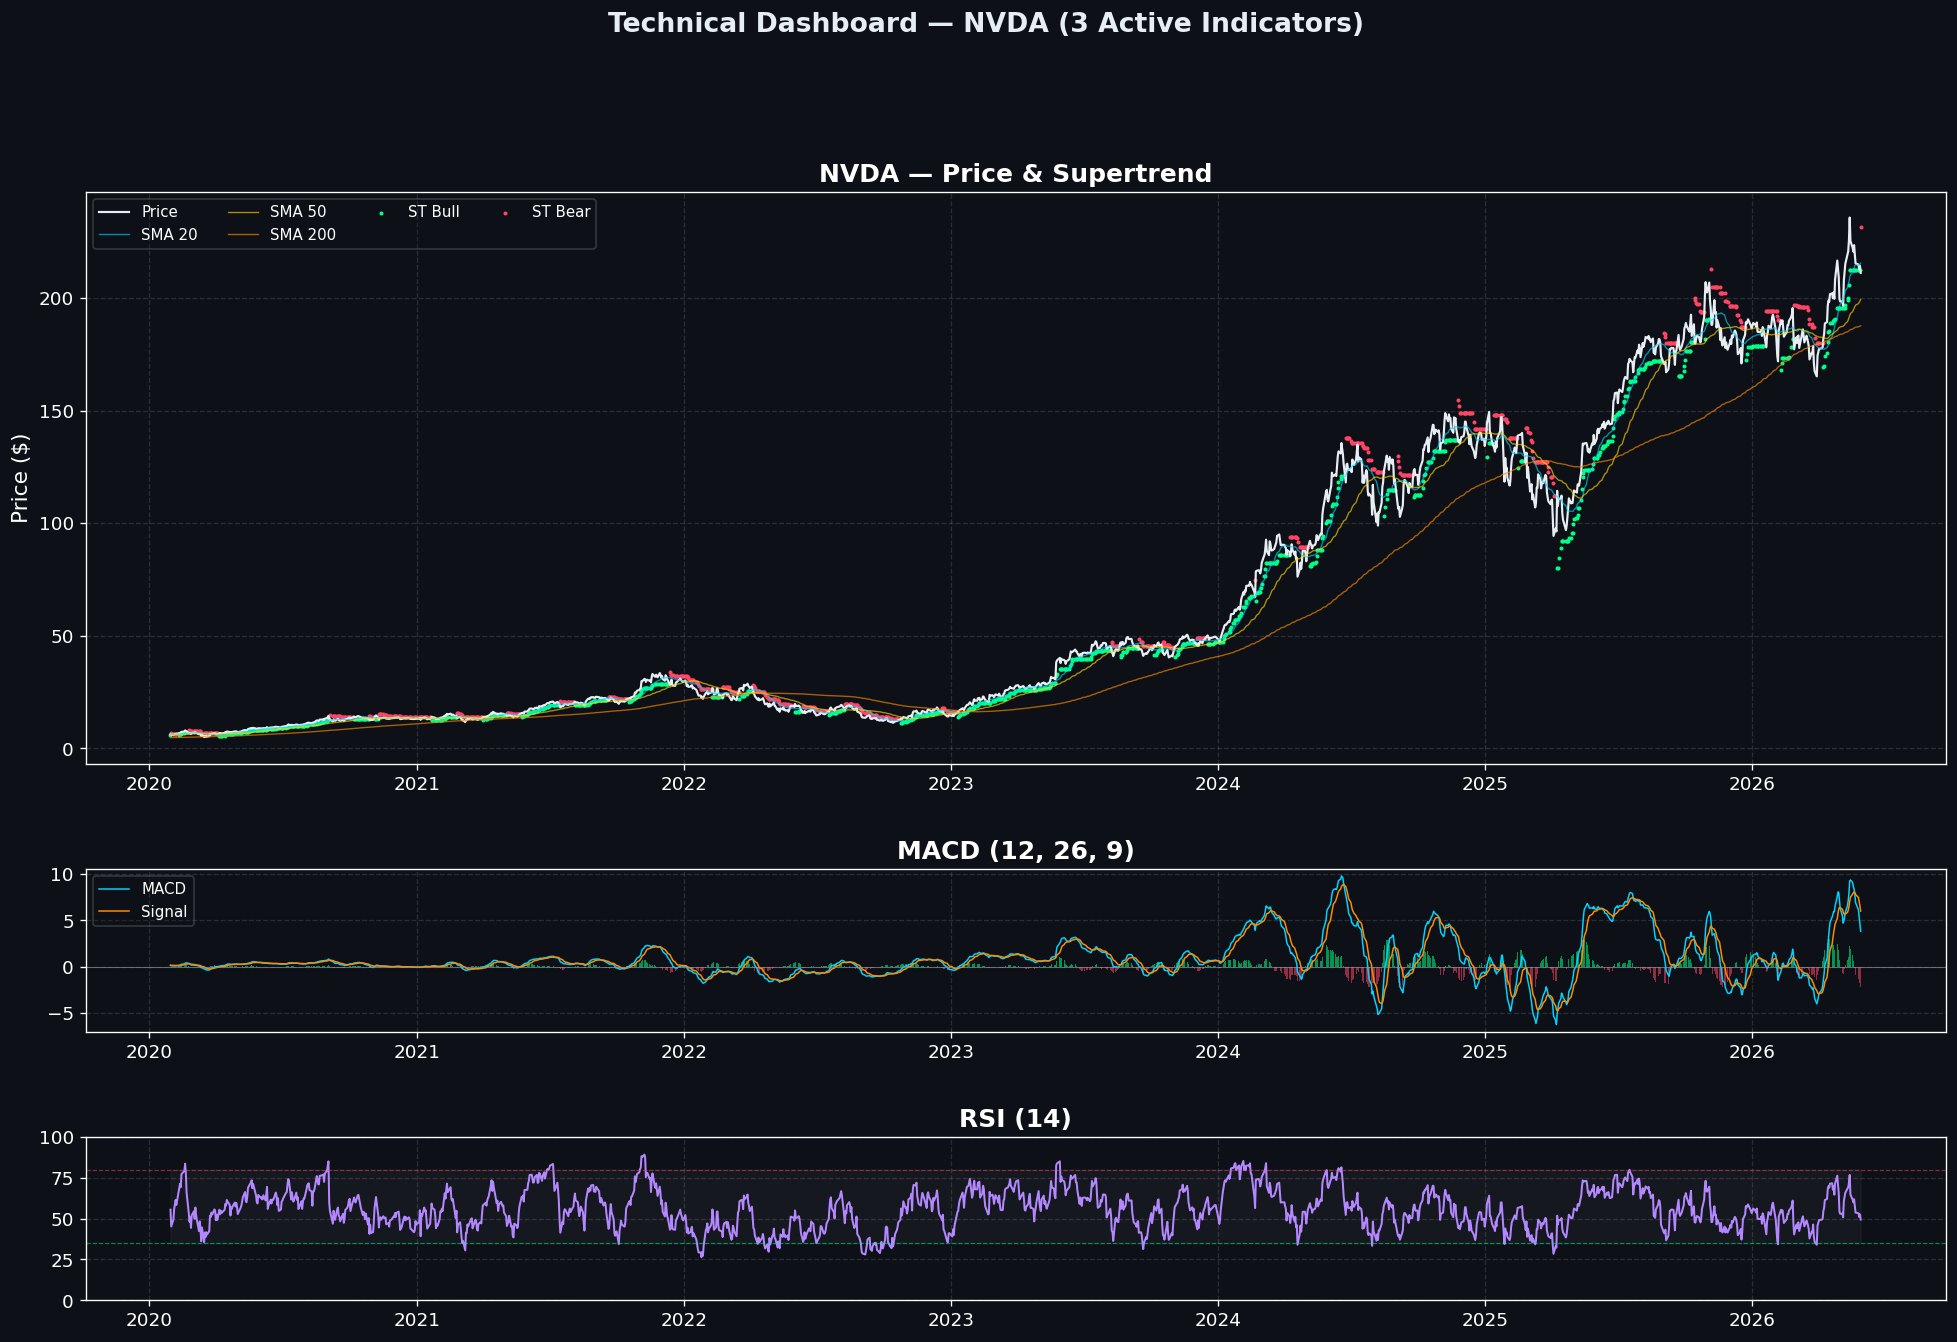

  Technical dashboard saved  ✓


In [10]:
SAMPLE = "NVDA"
fig = plt.figure(figsize=(20, 12))
gs_td = gridspec.GridSpec(3, 1, height_ratios=[3.5, 1, 1], hspace=0.35)

sl = slice(analysis_start, None)
c_ = adj_close[SAMPLE].loc[sl]
ind = IND[SAMPLE]

ax = fig.add_subplot(gs_td[0])
ax.plot(c_.index, c_, color=C["white"], lw=1.3, label="Price")
ax.plot(c_.index, ind["sma20"].loc[sl], color=C["cyan"], lw=0.8, alpha=0.65, label="SMA 20")
ax.plot(c_.index, ind["sma50"].loc[sl], color=C["yellow"], lw=0.8, alpha=0.65, label="SMA 50")
ax.plot(c_.index, ind["sma200"].loc[sl], color=C["orange"], lw=0.8, alpha=0.65, label="SMA 200")
st_d = ind["st_dir"].loc[sl]; st_v = ind["st"].loc[sl]
ax.scatter(st_v.index[st_d == 1],  st_v[st_d == 1],  s=2, color=C["green"], label="ST Bull")
ax.scatter(st_v.index[st_d == -1], st_v[st_d == -1], s=2, color=C["red"],   label="ST Bear")
ax.set_title(f"{SAMPLE} — Price & Supertrend")
ax.legend(ncol=4, framealpha=0.2, fontsize=9, loc="upper left")
ax.set_ylabel("Price ($)")

ax2 = fig.add_subplot(gs_td[1], sharex=ax)
mh = ind["macd_hist"].loc[sl]
ax2.bar(mh.index, mh, width=1,
        color=[C["green"] if v >= 0 else C["red"] for v in mh], alpha=0.55)
ax2.plot(mh.index, ind["macd"].loc[sl], color=C["cyan"], lw=0.9, label="MACD")
ax2.plot(mh.index, ind["macd_sig"].loc[sl], color=C["orange"], lw=0.9, label="Signal")
ax2.axhline(0, color=C["gray"], lw=0.4)
ax2.set_title("MACD (12, 26, 9)")
ax2.legend(framealpha=0.2, fontsize=9)

ax3 = fig.add_subplot(gs_td[2], sharex=ax)
rsi_ = ind["rsi"].loc[sl]
ax3.plot(rsi_.index, rsi_, color=C["purple"], lw=1.2)
ax3.axhline(P["rsi_overbought"], color=C["red"],   ls="--", alpha=0.5, lw=0.7)
ax3.axhline(P["rsi_oversold"],   color=C["green"], ls="--", alpha=0.5, lw=0.7)
ax3.fill_between(rsi_.index, P["rsi_oversold"], P["rsi_overbought"], alpha=0.04, color=C["white"])
ax3.set_ylim(0, 100)
ax3.set_title("RSI (14)")

fig.suptitle(f"Technical Dashboard — {SAMPLE} (3 Active Indicators)", fontsize=16,
             fontweight="bold", y=1.005, color=C["white"])
_save(fig, "03_technical_dashboard.png")
plt.show()
print("  Technical dashboard saved  ✓")


### Signal Generation Logic
Each indicator votes ±1. BUY if composite score ≥ 2, SELL if ≤ −2, else HOLD.

In [11]:
print("\n── Signal Generation ──")
print("  Strategy : MACD (trend) + RSI (momentum) + Supertrend (filter)")
print("  Scoring  :")
print("    MACD histogram > 0  →  +1  |  < 0  →  -1")
print("    RSI in [oversold, overbought]  →  +1  |  RSI ≥ 80  →  -1")
print("    Supertrend bullish  →  +2  |  bearish  →  -2")
print("    Composite ≥  2  →  BUY    |   ≤ -2  →  SELL    |  else HOLD")


def generate_signals(ac, hi, lo, vo, params=None):
    """Return (signals_df, scores_df) with daily signals per ticker."""
    if params is None:
        params = P
    signals = pd.DataFrame(0, index=ac.index, columns=ac.columns)
    scores  = pd.DataFrame(0.0, index=ac.index, columns=ac.columns)
    for t in ac.columns:
        c, h, l, v = ac[t], hi[t], lo[t], vo[t]
        _, _, mh = calc_macd(c, params["macd_fast"], params["macd_slow"], params["macd_signal"])
        rsi = calc_rsi(c, params["rsi_period"])
        _, sd = calc_supertrend(h, l, c, params["st_period"], params["st_mult"])

        ms = pd.Series(0, index=c.index)
        ms[mh > 0] = 1;  ms[mh < 0] = -1

        rs = pd.Series(0, index=c.index)
        rs[(rsi > params["rsi_oversold"]) & (rsi < params["rsi_overbought"])] = 1
        rs[rsi >= 80] = -1

        ss = sd * 1

        comp = ms + rs + ss
        scores[t] = comp
        signals.loc[comp >= 2, t] = 1
        signals.loc[comp <= -2, t] = -1
    return signals, scores

all_signals, all_scores = generate_signals(adj_close, high_df, low_df, volume_df)
monthly_signals = all_signals.resample("ME").last()

print("\n  Daily signal distribution:")
for t in TICKERS:
    b = (all_signals[t] == 1).sum()
    s = (all_signals[t] == -1).sum()
    h = (all_signals[t] == 0).sum()
    n = len(all_signals)
    print(f"    {t:>4s}  Buy {b:>5d} ({b/n*100:5.1f}%)  "
          f"Sell {s:>5d} ({s/n*100:5.1f}%)  Hold {h:>5d} ({h/n*100:5.1f}%)")


── Signal Generation ──
  Strategy : MACD (trend) + RSI (momentum) + Supertrend (filter)
  Scoring  :
    MACD histogram > 0  →  +1  |  < 0  →  -1
    RSI in [oversold, overbought]  →  +1  |  RSI ≥ 80  →  -1
    Supertrend bullish  →  +2  |  bearish  →  -2
    Composite ≥  2  →  BUY    |   ≤ -2  →  SELL    |  else HOLD

  Daily signal distribution:
    AAPL  Buy   592 ( 32.2%)  Sell   103 (  5.6%)  Hold  1146 ( 62.2%)
    MSFT  Buy   487 ( 26.5%)  Sell    88 (  4.8%)  Hold  1266 ( 68.8%)
    NVDA  Buy   745 ( 40.5%)  Sell    67 (  3.6%)  Hold  1029 ( 55.9%)
     JPM  Buy   435 ( 23.6%)  Sell    72 (  3.9%)  Hold  1334 ( 72.5%)
      GS  Buy   417 ( 22.7%)  Sell    89 (  4.8%)  Hold  1335 ( 72.5%)
     CAT  Buy   454 ( 24.7%)  Sell   134 (  7.3%)  Hold  1253 ( 68.1%)
     XOM  Buy   457 ( 24.8%)  Sell    94 (  5.1%)  Hold  1290 ( 70.1%)
      PG  Buy   214 ( 11.6%)  Sell    95 (  5.2%)  Hold  1532 ( 83.2%)
     JNJ  Buy    84 (  4.6%)  Sell   150 (  8.1%)  Hold  1607 ( 87.3%)
     PFE 

### Plot 4 — Signals on Sample Stock

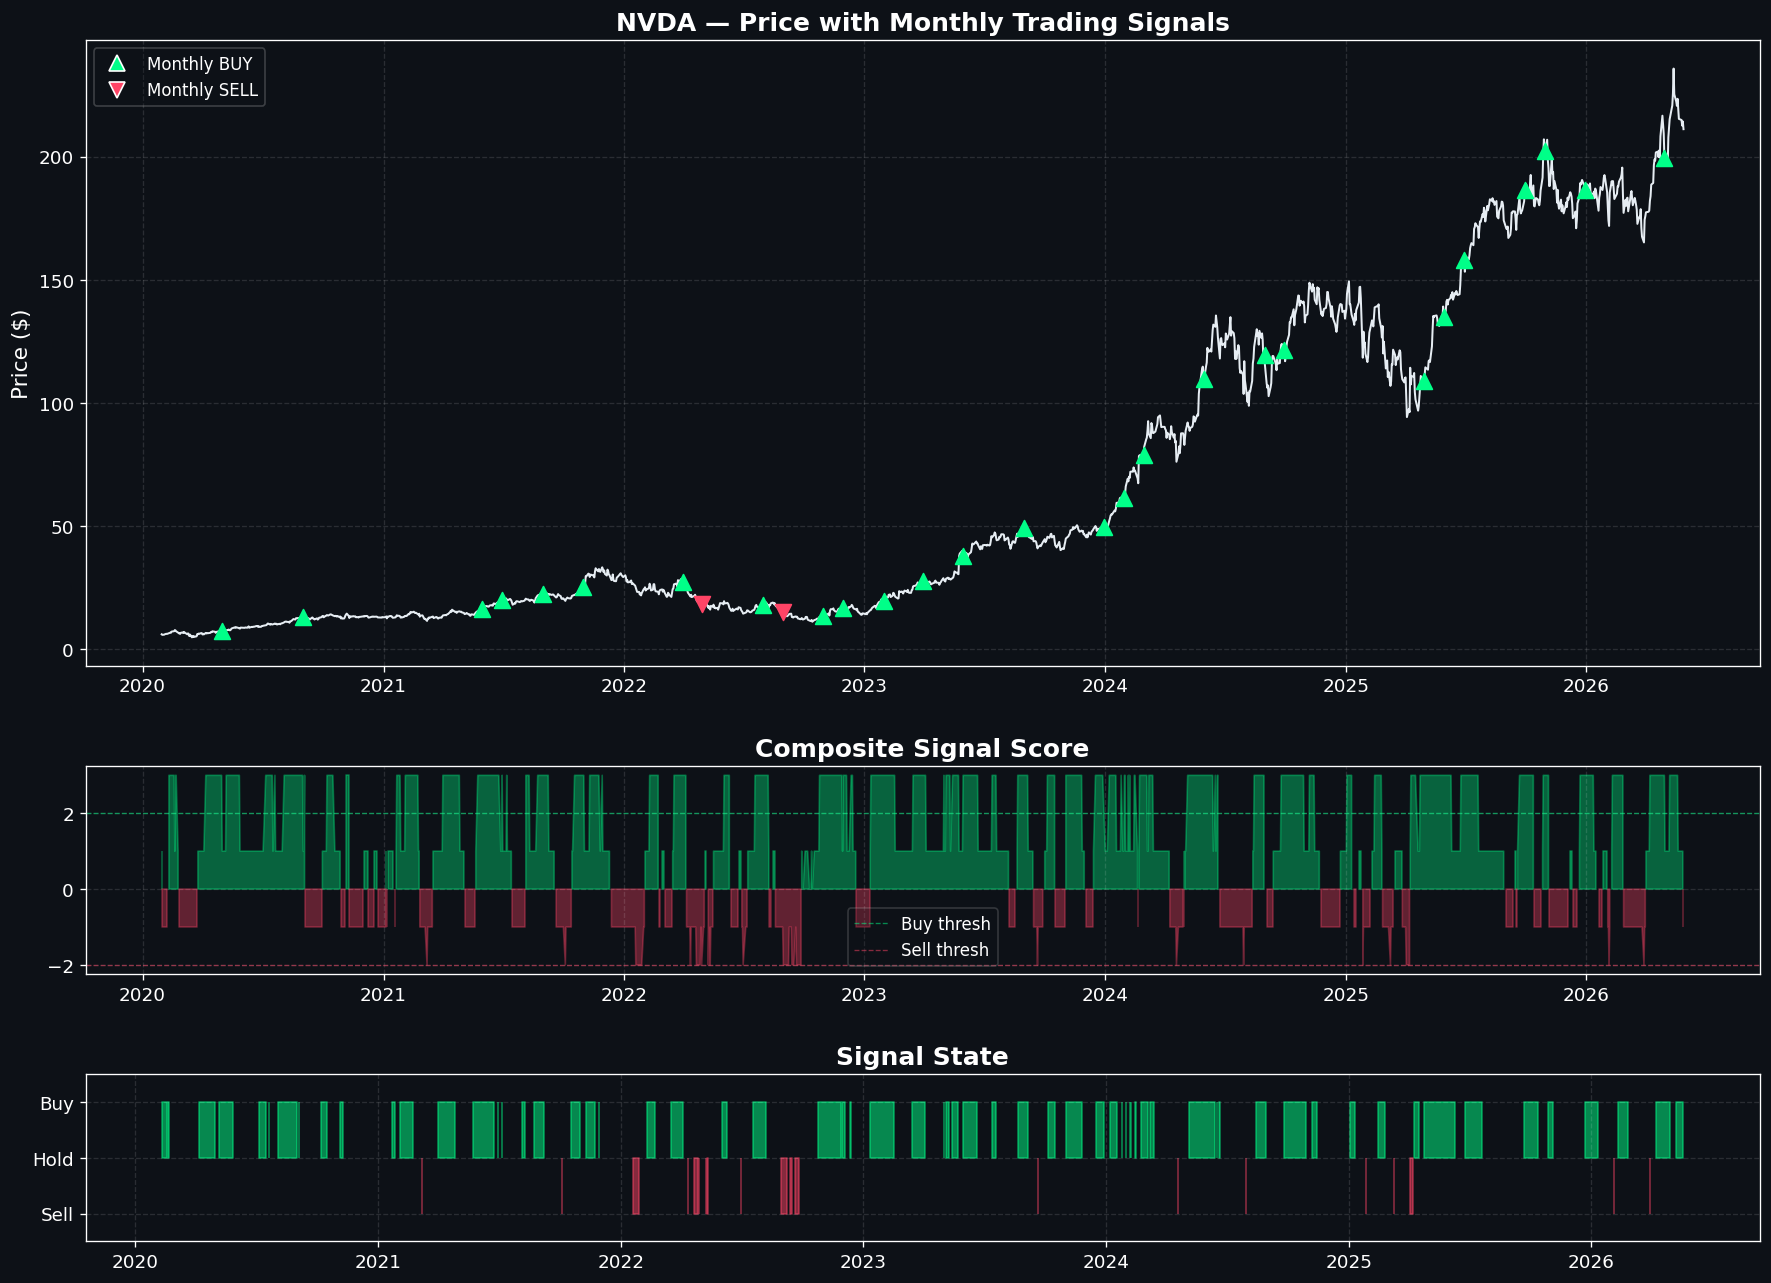

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(18, 13),
                         gridspec_kw={"height_ratios": [3, 1, 0.8], "hspace": 0.30})

c_ = adj_close[SAMPLE].loc[sl]
sig_ = all_signals[SAMPLE].loc[sl]
sc_  = all_scores[SAMPLE].loc[sl]

# Price + monthly markers
axes[0].plot(c_.index, c_, color=C["white"], lw=1.2)
ms_ = monthly_signals[SAMPLE]
mp_ = adj_close[SAMPLE].resample("ME").last()
for d in ms_[ms_ == 1].index:
    if d >= analysis_start and d in mp_.index:
        axes[0].scatter(d, mp_[d], marker="^", color=C["green"], s=90, zorder=5)
for d in ms_[ms_ == -1].index:
    if d >= analysis_start and d in mp_.index:
        axes[0].scatter(d, mp_[d], marker="v", color=C["red"], s=90, zorder=5)
legend_els = [Line2D([0], [0], marker="^", color="w", markerfacecolor=C["green"],
                     markersize=10, label="Monthly BUY", linestyle="None"),
              Line2D([0], [0], marker="v", color="w", markerfacecolor=C["red"],
                     markersize=10, label="Monthly SELL", linestyle="None")]
axes[0].legend(handles=legend_els, framealpha=0.25)
axes[0].set_title(f"{SAMPLE} — Price with Monthly Trading Signals")
axes[0].set_ylabel("Price ($)")

# Composite score
axes[1].fill_between(sc_.index, 0, sc_, where=sc_ >= 0, color=C["green"], alpha=0.35)
axes[1].fill_between(sc_.index, 0, sc_, where=sc_ < 0,  color=C["red"],   alpha=0.35)
axes[1].axhline( 2, color=C["green"], ls="--", alpha=0.5, lw=0.8, label="Buy thresh")
axes[1].axhline(-2, color=C["red"],   ls="--", alpha=0.5, lw=0.8, label="Sell thresh")
axes[1].set_title("Composite Signal Score")
axes[1].legend(framealpha=0.2)

# Signal bar
axes[2].fill_between(sig_.index, 0, sig_, where=sig_ > 0, color=C["green"], alpha=0.5, step="post")
axes[2].fill_between(sig_.index, 0, sig_, where=sig_ < 0, color=C["red"],   alpha=0.5, step="post")
axes[2].set_ylim(-1.5, 1.5);  axes[2].set_yticks([-1, 0, 1])
axes[2].set_yticklabels(["Sell", "Hold", "Buy"])
axes[2].set_title("Signal State")
_save(fig, "04_signals.png")
plt.show()

## Phase 3 — Backtesting Engine
Simulate portfolio performance with monthly rebalancing, 10 bps transaction costs, and no look-ahead bias.

In [13]:
def backtest(ac, sig_df, capital=INITIAL_CAPITAL, cost=TRANSACTION_COST,
             start=None, end=None):
    """
    Monthly-rebalanced backtest.
    • Month-end signals → execute on first trading day of next month
    • Equal-weight among all BUY-flagged stocks (HOLD keeps prev. state)
    • 10 bps round-trip cost per trade (applied to absolute turnover)
    Returns portfolio value series, dict of monthly turnover, daily returns
    """
    ac = ac.copy()
    if start: ac = ac.loc[start:]
    if end:   ac = ac.loc[:end]

    me_sig = sig_df.reindex(ac.index).resample("ME").last()

    port = pd.Series(np.nan, index=ac.index)
    shares = pd.Series(0.0, index=ac.columns)
    cash   = capital
    held   = set()
    turnover = {}

    # Map month-end → next month's first trading day
    me_to_fd = {}
    for med in me_sig.index:
        nxt = ac.index[ac.index > med]
        if len(nxt):
            me_to_fd[med] = nxt[0]
    rebal_dates = set(me_to_fd.values())

    for date in ac.index:
        # Mark-to-market
        val = cash + (shares * ac.loc[date]).sum()
        port[date] = val

        if date not in rebal_dates:
            continue

        # Determine which signal date maps here
        sig_date = None
        for md, fd in me_to_fd.items():
            if fd == date:
                sig_date = md; break
        if sig_date is None or sig_date not in me_sig.index:
            continue

        s = me_sig.loc[sig_date]
        new_held = set()
        for t in ac.columns:
            if s[t] == 1:
                new_held.add(t)
            elif s[t] == 0 and t in held:
                new_held.add(t)   # HOLD keeps position

        # Compute trade values
        old_vals = {t: shares[t] * ac.loc[date, t] for t in ac.columns}
        total_val = cash + sum(old_vals.values())

        if len(new_held) == 0:
            # Go full cash
            trade_abs = sum(abs(old_vals[t]) for t in ac.columns if old_vals[t] > 0)
            tc = trade_abs * cost
            cash = total_val - tc
            shares[:] = 0.0
            turnover[date] = trade_abs / total_val if total_val else 0
        else:
            target_w = 1.0 / len(new_held)
            trade_abs = 0
            for t in ac.columns:
                tgt = total_val * target_w if t in new_held else 0
                trade_abs += abs(tgt - old_vals[t])
            tc = trade_abs * cost
            available = total_val - tc
            per_stock = available / len(new_held) if len(new_held) else 0
            cash = 0.0
            for t in ac.columns:
                price = ac.loc[date, t]
                shares[t] = per_stock / price if (t in new_held and price > 0) else 0
            turnover[date] = trade_abs / total_val if total_val else 0

        held = new_held
        port[date] = cash + (shares * ac.loc[date]).sum()

    port = port.dropna()
    return port, turnover


def benchmark_bh(ac, capital=INITIAL_CAPITAL, start=None):
    """Equal-weight buy-and-hold benchmark."""
    ac = ac.copy()
    if start: ac = ac.loc[start:]
    n = len(ac.columns)
    per = capital / n
    sh = per / ac.iloc[0]
    return (sh * ac).sum(axis=1)

### Run Full-Period Backtest & Metrics
financial metrics to compare my strategy
against a simple baseline.

In [14]:
# ── Run full-period backtest ─────────────────────────────────────
pv, to = backtest(adj_close, all_signals, start=analysis_start)
bm     = benchmark_bh(adj_close, start=analysis_start)

# Align
ci = pv.index.intersection(bm.index)
pv, bm = pv[ci], bm[ci]

# ── Metrics helper ───────────────────────────────────────────────
def metrics(pv_series, label="Strategy", rf=RISK_FREE):
    r = pv_series.pct_change().dropna()
    years = (pv_series.index[-1] - pv_series.index[0]).days / 365.25
    
    # Core Returns
    tot = pv_series.iloc[-1] / pv_series.iloc[0] - 1
    cagr = (1 + tot) ** (1 / years) - 1
    ann_v = r.std() * np.sqrt(252)
    
    # Sharpe Ratio
    sharpe = (r.mean() - rf / 252) / r.std() * np.sqrt(252) if r.std() else 0
    
    # Sortino Ratio (Downside deviation)
    downside_diff = r - 0  # MAR = 0
    downside_sq = np.where(downside_diff < 0, downside_diff**2, 0)
    down_std = np.sqrt(np.mean(downside_sq)) * np.sqrt(252)
    sortino = (cagr - rf) / down_std if down_std > 0 else 0
    
    # Drawdown & Calmar
    dd = pv_series / pv_series.cummax() - 1
    mdd = dd.min()
    calmar = cagr / abs(mdd) if mdd != 0 else np.inf
    
    # Monthly Win Rate
    mr = pv_series.resample("ME").last().pct_change().dropna()
    win_rate = (mr > 0).mean() if len(mr) > 0 else 0
    
    return {
        "Label": label,
        "Total Return":        tot,
        "CAGR":                cagr,
        "Ann. Volatility":     ann_v,
        "Sharpe Ratio":        sharpe,
        "Sortino Ratio":       sortino,
        "Calmar Ratio":        calmar,
        "Max Drawdown":        mdd,
        "Monthly Win Rate":    win_rate,
        "End Value":           pv_series.iloc[-1],
    }, dd, r

sm, s_dd, s_ret = metrics(pv, "MM v7.0")
bm_m, b_dd, b_ret = metrics(bm, "EW Benchmark")

print(f"\n  Backtest : {pv.index[0].date()} → {pv.index[-1].date()}")
print(f"  Capital  : ${INITIAL_CAPITAL:,.0f}\n")

print(f"  {sm['Label']}  vs  {bm_m['Label']}")
print(f"  {'Metric':<22s} {sm['Label']:>16s} {bm_m['Label']:>18s}")
print("  " + "─" * 66)

metric_keys = ["Total Return", "CAGR", "Ann. Volatility", "Sharpe Ratio", 
               "Sortino Ratio", "Calmar Ratio", "Max Drawdown", "Monthly Win Rate", "End Value"]

for k in metric_keys:
    sv, bv = sm[k], bm_m[k]
    if k == "End Value":
        print(f"  {k:<22s} {'$'+f'{sv:,.0f}':>16s} {'$'+f'{bv:,.0f}':>18s}")
    elif k in ["Total Return", "CAGR", "Ann. Volatility", "Max Drawdown"]:
        print(f"  {k:<22s} {sv*100:>15.2f}% {bv*100:>17.2f}%")
    elif k == "Monthly Win Rate":
        print(f"  {k:<22s} {sv*100:>15.1f}% {bv*100:>17.1f}%")
    else:
        print(f"  {k:<22s} {sv:>16.4f} {bv:>18.4f}")

print("\n  -- Alpha vs Benchmark --")
print(f"  CAGR delta        :  {(sm['CAGR'] - bm_m['CAGR'])*100:+.2f}%")
print(f"  Sharpe delta      :  {(sm['Sharpe Ratio'] - bm_m['Sharpe Ratio']):+.4f}")
print(f"  Sortino delta     :  {(sm['Sortino Ratio'] - bm_m['Sortino Ratio']):+.4f}")
print(f"  Calmar delta      :  {(sm['Calmar Ratio'] - bm_m['Calmar Ratio']):+.4f}")
print(f"  MDD improvement   :  {(sm['Max Drawdown'] - bm_m['Max Drawdown'])*100:+.2f}%")

# ── Turnover ─────────────────────────────────────────────────────
to_s = pd.Series(to).sort_index()
print(f"\n  Average monthly turnover : {to_s.mean()*100:.2f}%")


  Backtest : 2020-01-30 → 2026-05-29
  Capital  : $1,000,000

  MM v7.0  vs  EW Benchmark
  Metric                          MM v7.0       EW Benchmark
  ──────────────────────────────────────────────────────────────────
  Total Return                    737.25%            532.01%
  CAGR                             39.91%             33.83%
  Ann. Volatility                  24.74%             27.01%
  Sharpe Ratio                     1.3241             1.0694
  Sortino Ratio                    2.1887             1.6321
  Calmar Ratio                     1.4234             1.0448
  Max Drawdown                    -28.04%            -32.38%
  Monthly Win Rate                  72.4%              68.4%
  End Value                    $8,372,503         $6,320,127

  -- Alpha vs Benchmark --
  CAGR delta        :  +6.08%
  Sharpe delta      :  +0.2547
  Sortino delta     :  +0.5566
  Calmar delta      :  +0.3786
  MDD improvement   :  +4.34%

  Average monthly turnover : 20.29%


## Phase 4 & 5 — Performance Metrics & Visualisation
Full-period results shown here; overfitting checks follow below

### Plot 5 — Equity Curve (log)


════════════════════════════════════════════════════════════════════════
  PHASE 5 · PERFORMANCE VISUALISATION (full period)
════════════════════════════════════════════════════════════════════════


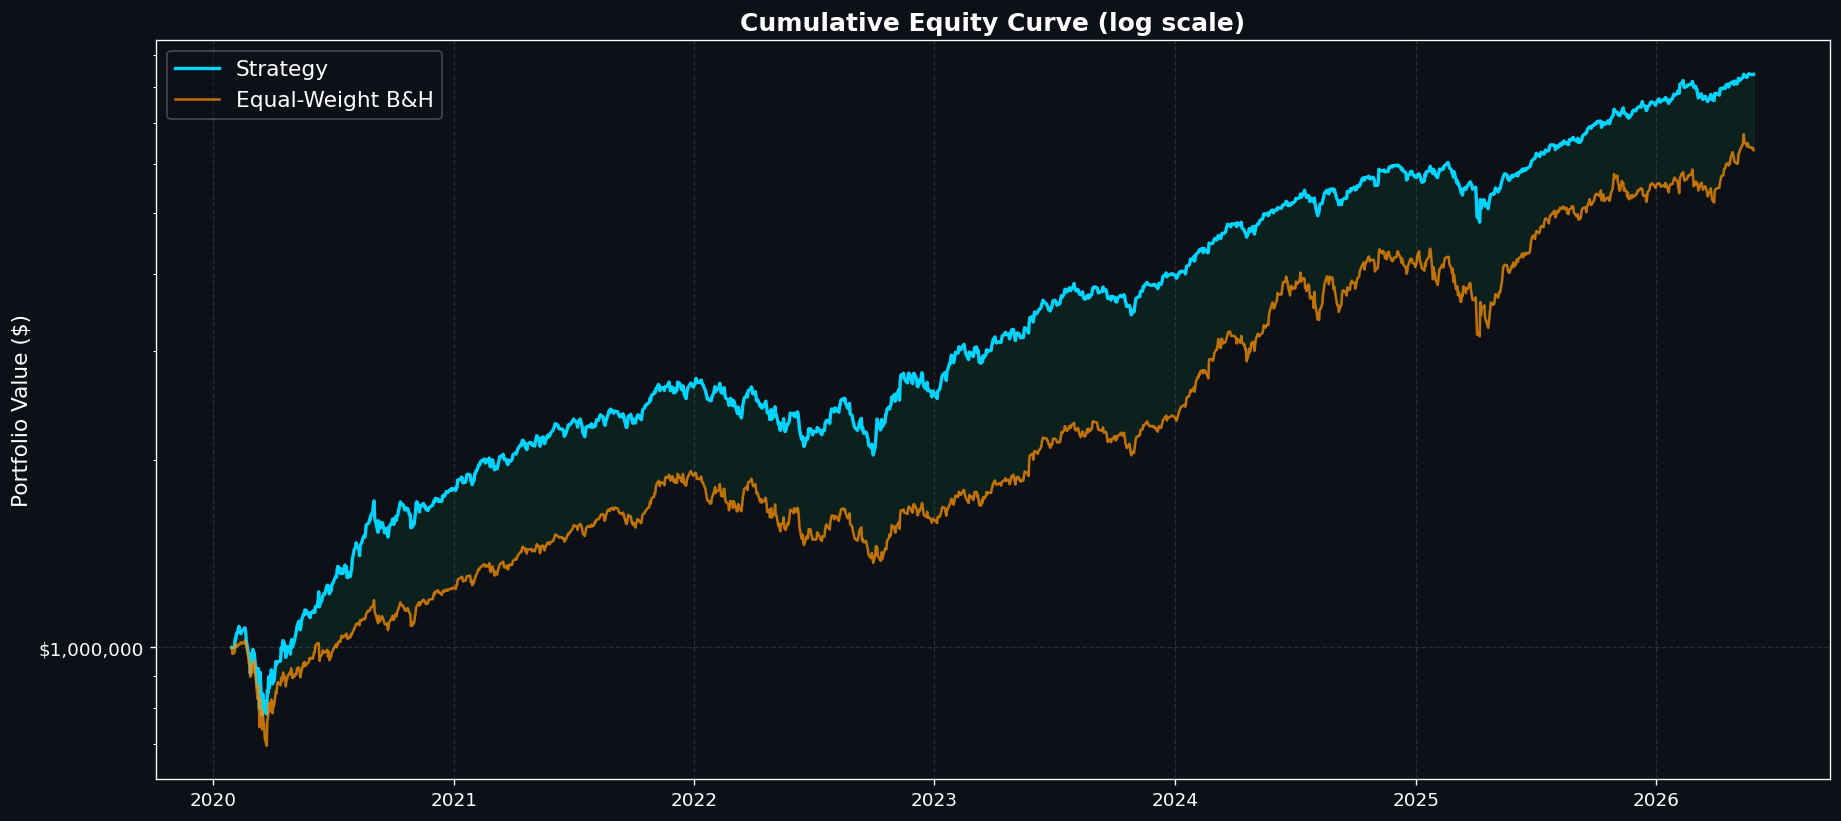

In [15]:
print("\n" + "═" * 72)
print("  PHASE 5 · PERFORMANCE VISUALISATION (full period)")
print("═" * 72)

fig, ax = plt.subplots(figsize=(18, 8))
ax.plot(pv.index, pv, color=C["cyan"], lw=2, label="Strategy")
ax.plot(bm.index, bm, color=C["orange"], lw=1.5, alpha=0.75, label="Equal-Weight B&H")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_title("Cumulative Equity Curve (log scale)")
ax.set_ylabel("Portfolio Value ($)")
ax.legend(fontsize=13, framealpha=0.3)
ax.fill_between(pv.index, pv, bm,
                where=pv >= bm, color=C["green"], alpha=0.07)
ax.fill_between(pv.index, pv, bm,
                where=pv < bm, color=C["red"], alpha=0.07)
_save(fig, "05_equity_curve.png")
plt.show()

### Plot 6 — Drawdown

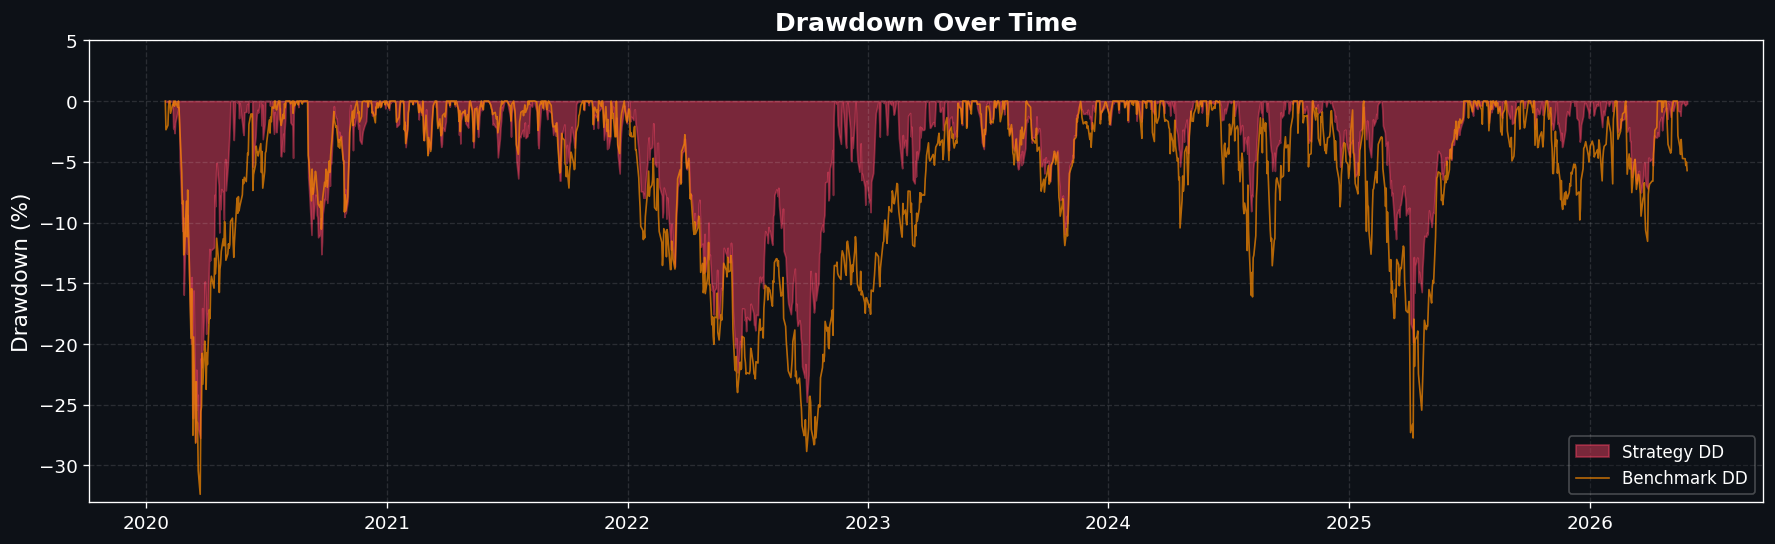

In [16]:
fig, ax = plt.subplots(figsize=(18, 5))
ax.fill_between(s_dd.index, s_dd * 100, 0, color=C["red"], alpha=0.45, label="Strategy DD")
ax.plot(b_dd.index, b_dd * 100, color=C["orange"], lw=1, alpha=0.7, label="Benchmark DD")
ax.set_title("Drawdown Over Time")
ax.set_ylabel("Drawdown (%)")
ax.legend(framealpha=0.3)
ax.set_ylim(s_dd.min() * 100 - 5, 5)
_save(fig, "06_drawdown.png")
plt.show()

### Plot 7 — Rolling 6-Month Sharpe Ratio *(PS Required)*

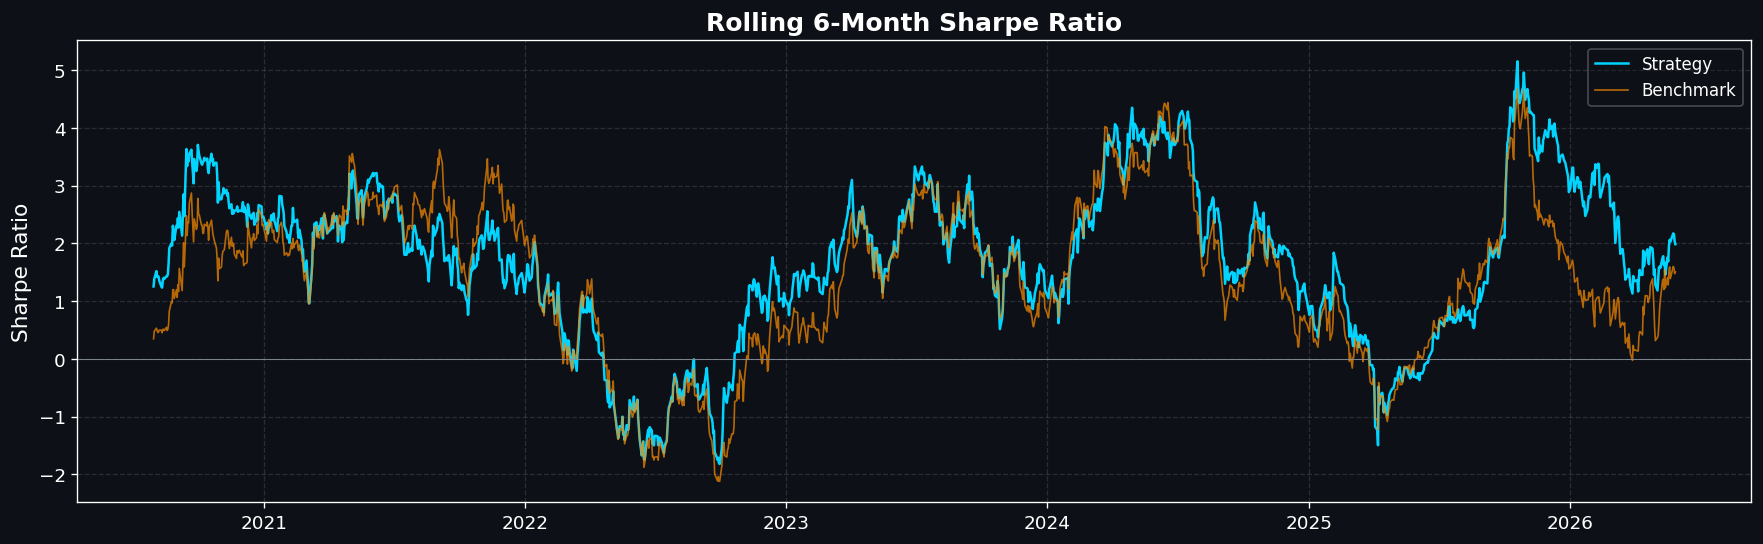

In [17]:
window = 126   # ~6 trading months
rolling_sharpe = (
    (s_ret.rolling(window).mean() - RISK_FREE / 252)
    / s_ret.rolling(window).std() * np.sqrt(252)
)
bench_rolling_sharpe = (
    (b_ret.rolling(window).mean() - RISK_FREE / 252)
    / b_ret.rolling(window).std() * np.sqrt(252)
)

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(rolling_sharpe.index, rolling_sharpe, color=C["cyan"], lw=1.5, label="Strategy")
ax.plot(bench_rolling_sharpe.index, bench_rolling_sharpe, color=C["orange"],
        lw=1, alpha=0.7, label="Benchmark")
ax.axhline(0, color=C["gray"], lw=0.5)
ax.set_title("Rolling 6-Month Sharpe Ratio")
ax.set_ylabel("Sharpe Ratio")
ax.legend(framealpha=0.3)
_save(fig, "07_rolling_sharpe.png")
plt.show()

### Plot 8 — Monthly Portfolio Turnover *(PS Required)*

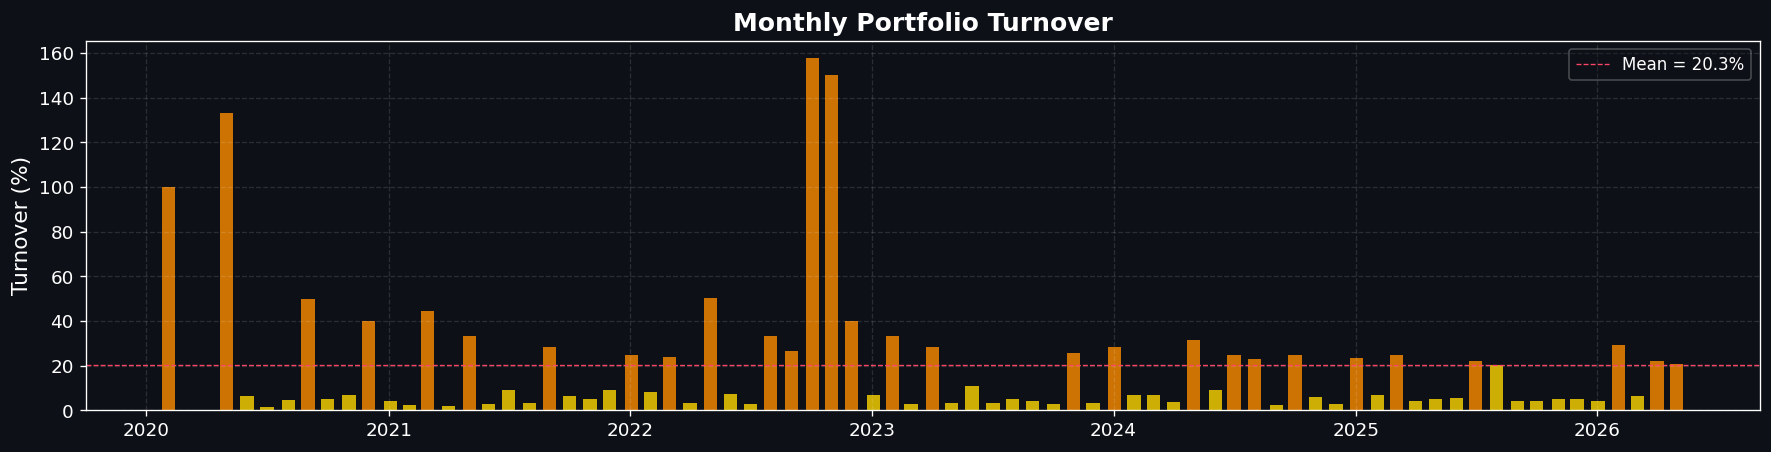

In [18]:
fig, ax = plt.subplots(figsize=(18, 4))
if len(to_s):
    ax.bar(to_s.index, to_s * 100,
           color=[C["yellow"] if v < to_s.mean() else C["orange"] for v in to_s],
           width=20, alpha=0.8)
    ax.axhline(to_s.mean() * 100, color=C["red"], ls="--", lw=0.8,
               label=f"Mean = {to_s.mean()*100:.1f}%")
    ax.set_title("Monthly Portfolio Turnover")
    ax.set_ylabel("Turnover (%)")
    ax.legend(framealpha=0.3)
_save(fig, "08_turnover.png")
plt.show()

## Phase 4 — Overfitting Mitigation
Three methods to prove the strategy is not overfit: Train/Test Split, Walk-Forward Optimisation, and Parameter Sensitivity.

### 4A. Train / Test Split (Out-of-Sample Testing)
Train on first 5 years, test on remaining 2 years.

In [19]:
print("  PHASE 4 · OVERFITTING MITIGATION")

total_days = (adj_close.index[-1] - analysis_start).days
split_date = analysis_start + timedelta(days=int(TRAIN_YEARS / (TRAIN_YEARS + TEST_YEARS) * total_days))
# Snap to nearest trading day
split_date = adj_close.index[adj_close.index >= split_date][0]

print(f"  Train : {analysis_start.date()} → {split_date.date()}")
print(f"  Test  : {split_date.date()} → {adj_close.index[-1].date()}")

# In-sample backtest
pv_train, _ = backtest(adj_close, all_signals, start=analysis_start, end=split_date)
bm_train     = benchmark_bh(adj_close, start=analysis_start).loc[:split_date]

# Out-of-sample backtest (signals were generated on full data indicators,
# but that's fine — we're testing fixed rules, not optimised params)
pv_test, _ = backtest(adj_close, all_signals, start=split_date)
bm_test    = benchmark_bh(adj_close, start=split_date)

ci_tr = pv_train.index.intersection(bm_train.index)
ci_te = pv_test.index.intersection(bm_test.index)
pv_train, bm_train = pv_train[ci_tr], bm_train[ci_tr]
pv_test,  bm_test  = pv_test[ci_te],  bm_test[ci_te]

m_tr, _, _ = metrics(pv_train, "Train")
m_te, _, _ = metrics(pv_test,  "Test")
b_tr, _, _ = metrics(bm_train, "BM Train")
b_te, _, _ = metrics(bm_test,  "BM Test")

print(f"\n  {'Metric':<24s} {'Train':>10s} {'Test':>10s}  |  {'BM Train':>10s} {'BM Test':>10s}")
print("  " + "─" * 70)
for k in ["CAGR", "Sharpe Ratio", "Max Drawdown"]:
    print(f"  {k:<24s} {m_tr[k]:>10.4f} {m_te[k]:>10.4f}  |  "
          f"{b_tr[k]:>10.4f} {b_te[k]:>10.4f}")

  PHASE 4 · OVERFITTING MITIGATION
  Train : 2020-01-30 → 2024-08-06
  Test  : 2024-08-06 → 2026-05-29

  Metric                        Train       Test  |    BM Train    BM Test
  ──────────────────────────────────────────────────────────────────────
  CAGR                         0.4298     0.2878  |      0.3152     0.2968
  Sharpe Ratio                 1.3076     1.3065  |      1.0292     1.4145
  Max Drawdown                -0.2804    -0.2206  |     -0.3238    -0.1952


### Plot 10 — Train / Test Equity

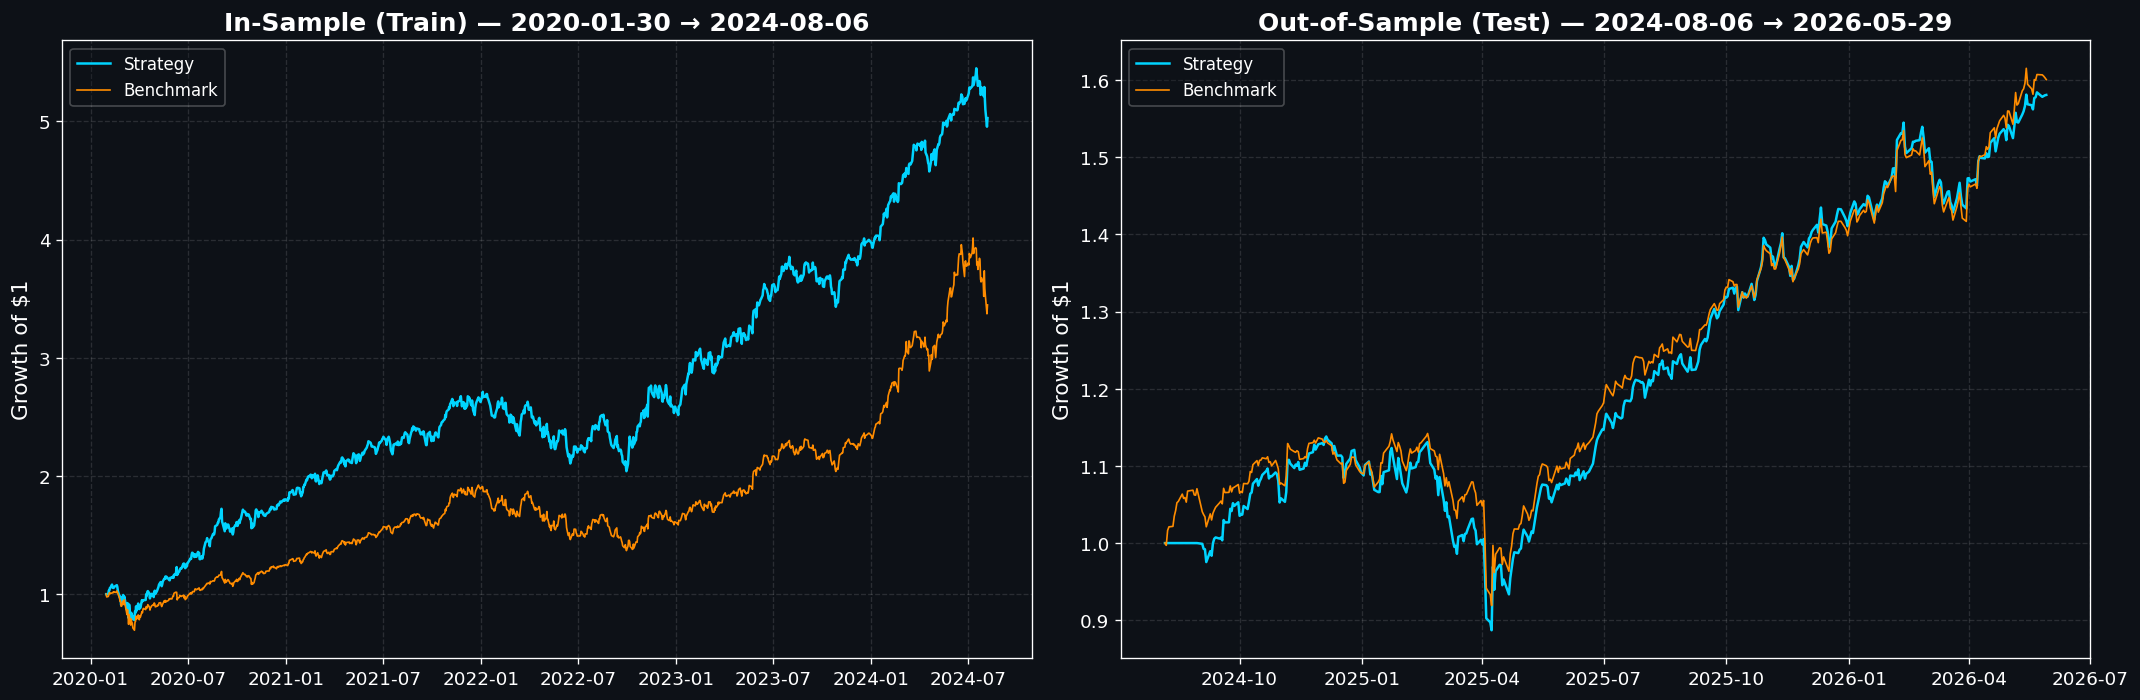

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].plot(pv_train.index, pv_train / pv_train.iloc[0], color=C["cyan"], lw=1.5, label="Strategy")
axes[0].plot(bm_train.index, bm_train / bm_train.iloc[0], color=C["orange"], lw=1, label="Benchmark")
axes[0].set_title(f"In-Sample (Train) — {analysis_start.date()} → {split_date.date()}")
axes[0].legend(framealpha=0.3);  axes[0].set_ylabel("Growth of $1")

axes[1].plot(pv_test.index, pv_test / pv_test.iloc[0], color=C["cyan"], lw=1.5, label="Strategy")
axes[1].plot(bm_test.index, bm_test / bm_test.iloc[0], color=C["orange"], lw=1, label="Benchmark")
axes[1].set_title(f"Out-of-Sample (Test) — {split_date.date()} → {adj_close.index[-1].date()}")
axes[1].legend(framealpha=0.3);  axes[1].set_ylabel("Growth of $1")
plt.tight_layout()
_save(fig, "10_train_test_split.png")
plt.show()

### 4B. Walk-Forward Optimisation
Rolling 36-month train / 6-month test windows.

In [21]:
print("\n Walk-Forward Optimisation ")
print("  Rolling 36-month train / 6-month test windows")
print("  Optimising: RSI thresholds, Supertrend multiplier")

# Parameter grid (kept small for speed)
RSI_OS_GRID  = [30, 35, 40]
RSI_OB_GRID  = [70, 75, 80]
ST_MULT_GRID = [2.0, 2.5, 3.0, 3.5]

TRAIN_MONTHS = 36
TEST_MONTHS  = 6

monthly_dates = adj_close.loc[analysis_start:].resample("ME").last().index
wf_results = []

n_windows = (len(monthly_dates) - TRAIN_MONTHS - TEST_MONTHS) // TEST_MONTHS + 1
print(f"  Windows : {n_windows}")

for w in range(n_windows):
    tr_start_idx = w * TEST_MONTHS
    tr_end_idx   = tr_start_idx + TRAIN_MONTHS - 1
    te_start_idx = tr_end_idx + 1
    te_end_idx   = te_start_idx + TEST_MONTHS - 1

    if te_end_idx >= len(monthly_dates):
        break

    tr_start = monthly_dates[tr_start_idx]
    tr_end   = monthly_dates[tr_end_idx]
    te_start = monthly_dates[te_start_idx]
    te_end   = monthly_dates[te_end_idx]

    # ─ Grid search on training window ─
    best_sharpe = -999
    best_p = None
    for os_t, ob_t, st_m in product(RSI_OS_GRID, RSI_OB_GRID, ST_MULT_GRID):
        if os_t >= ob_t:
            continue
        trial_p = P.copy()
        trial_p["rsi_oversold"] = os_t
        trial_p["rsi_overbought"] = ob_t
        trial_p["st_mult"] = st_m
        sig_tr, _ = generate_signals(adj_close, high_df, low_df, volume_df, trial_p)
        pv_tr, _ = backtest(adj_close, sig_tr, start=tr_start, end=tr_end)
        if len(pv_tr) < 30:
            continue
        r = pv_tr.pct_change().dropna()
        sh = (r.mean() - RISK_FREE / 252) / r.std() * np.sqrt(252) if r.std() > 0 else -999
        if sh > best_sharpe:
            best_sharpe = sh
            best_p = trial_p.copy()

    # ─ Test with best params ─
    if best_p is None:
        best_p = P.copy()
    sig_te, _ = generate_signals(adj_close, high_df, low_df, volume_df, best_p)
    pv_te, _ = backtest(adj_close, sig_te, start=te_start, end=te_end)
    if len(pv_te) < 10:
        continue
    r_te = pv_te.pct_change().dropna()
    sh_te = ((r_te.mean() - RISK_FREE / 252) / r_te.std() * np.sqrt(252)
             if r_te.std() > 0 else 0)
    tot_te = pv_te.iloc[-1] / pv_te.iloc[0] - 1

    wf_results.append({
        "window": w,
        "train": f"{tr_start.date()}→{tr_end.date()}",
        "test":  f"{te_start.date()}→{te_end.date()}",
        "train_sharpe": best_sharpe,
        "test_sharpe":  sh_te,
        "test_return":  tot_te,
        "best_rsi_os":  best_p["rsi_oversold"],
        "best_rsi_ob":  best_p["rsi_overbought"],
        "best_st_mult": best_p["st_mult"],
        "pv_test":      pv_te,
    })
    print(f"    Window {w:>2d}  Train Sharpe={best_sharpe:+.3f}  "
          f"Test Sharpe={sh_te:+.3f}  Test Ret={tot_te*100:+.1f}%  "
          f"Params: RSI=[{best_p['rsi_oversold']},{best_p['rsi_overbought']}] ST={best_p['st_mult']}")

wf_df = pd.DataFrame(wf_results)
if len(wf_df):
    print(f"\n  Walk-Forward Summary:")
    print(f"    Avg Test Sharpe  : {wf_df['test_sharpe'].mean():.3f}")
    print(f"    Avg Test Return  : {wf_df['test_return'].mean()*100:.2f}%")
    print(f"    % Windows Profitable : {(wf_df['test_return'] > 0).mean()*100:.0f}%")


 Walk-Forward Optimisation 
  Rolling 36-month train / 6-month test windows
  Optimising: RSI thresholds, Supertrend multiplier
  Windows : 6
    Window  0  Train Sharpe=+1.486  Test Sharpe=+3.404  Test Ret=+43.9%  Params: RSI=[40,70] ST=2.0
    Window  1  Train Sharpe=+1.447  Test Sharpe=-0.496  Test Ret=-2.2%  Params: RSI=[35,70] ST=2.0
    Window  2  Train Sharpe=+1.011  Test Sharpe=+3.475  Test Ret=+25.4%  Params: RSI=[35,70] ST=3.5
    Window  3  Train Sharpe=+1.202  Test Sharpe=+0.795  Test Ret=+8.0%  Params: RSI=[35,70] ST=2.5
    Window  4  Train Sharpe=+1.266  Test Sharpe=+0.186  Test Ret=+2.2%  Params: RSI=[35,70] ST=3.5
    Window  5  Train Sharpe=+1.733  Test Sharpe=+1.485  Test Ret=+12.7%  Params: RSI=[30,70] ST=3.5

  Walk-Forward Summary:
    Avg Test Sharpe  : 1.475
    Avg Test Return  : 15.02%
    % Windows Profitable : 83%


### Plot 11 — Walk-Forward Results

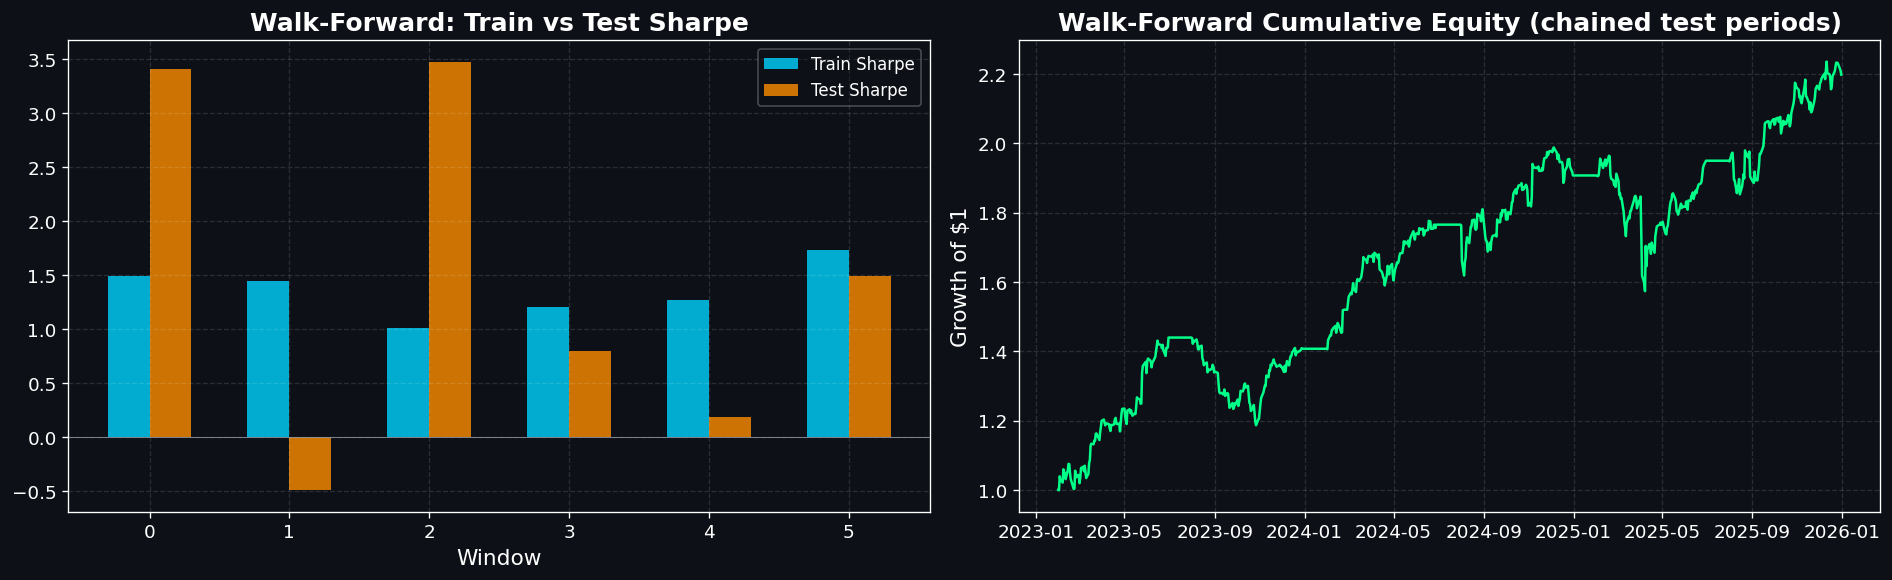

In [22]:
if len(wf_df):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    x = wf_df["window"]
    axes[0].bar(x - 0.15, wf_df["train_sharpe"], 0.3, label="Train Sharpe",
                color=C["cyan"], alpha=0.8)
    axes[0].bar(x + 0.15, wf_df["test_sharpe"], 0.3, label="Test Sharpe",
                color=C["orange"], alpha=0.8)
    axes[0].axhline(0, color=C["gray"], lw=0.5)
    axes[0].set_title("Walk-Forward: Train vs Test Sharpe")
    axes[0].set_xlabel("Window")
    axes[0].legend(framealpha=0.3)

    # Concatenated walk-forward equity curve
    wf_equity = pd.Series(dtype=float)
    for row in wf_results:
        eq = row["pv_test"] / row["pv_test"].iloc[0]
        if len(wf_equity):
            eq = eq * wf_equity.iloc[-1]
        wf_equity = pd.concat([wf_equity, eq])
    wf_equity = wf_equity[~wf_equity.index.duplicated(keep="last")]
    axes[1].plot(wf_equity.index, wf_equity, color=C["green"], lw=1.5)
    axes[1].set_title("Walk-Forward Cumulative Equity (chained test periods)")
    axes[1].set_ylabel("Growth of $1")
    plt.tight_layout()
    _save(fig, "11_walk_forward.png")
    plt.show()

### 4C. Parameter Sensitivity
Vary each key parameter ±20% to confirm strategy robustness.

In [23]:
print("\n── 4C  Parameter Sensitivity ──")
print("  Varying each key parameter ±20% and measuring Sharpe impact")

sensitivity = {}

# RSI oversold threshold
results_os = []
for val in [25, 30, 35, 40, 45]:
    tp = P.copy(); tp["rsi_oversold"] = val
    sig, _ = generate_signals(adj_close, high_df, low_df, volume_df, tp)
    pv_, _ = backtest(adj_close, sig, start=analysis_start)
    m_, _, _ = metrics(pv_)
    results_os.append({"param": val, "sharpe": m_["Sharpe Ratio"], "ret": m_["CAGR"]})
sensitivity["RSI Oversold"] = pd.DataFrame(results_os)

# RSI overbought threshold
results_ob = []
for val in [65, 70, 75, 80, 85]:
    tp = P.copy(); tp["rsi_overbought"] = val
    sig, _ = generate_signals(adj_close, high_df, low_df, volume_df, tp)
    pv_, _ = backtest(adj_close, sig, start=analysis_start)
    m_, _, _ = metrics(pv_)
    results_ob.append({"param": val, "sharpe": m_["Sharpe Ratio"], "ret": m_["CAGR"]})
sensitivity["RSI Overbought"] = pd.DataFrame(results_ob)

# Supertrend multiplier
results_st = []
for val in [2.0, 2.5, 3.0, 3.5, 4.0]:
    tp = P.copy(); tp["st_mult"] = val
    sig, _ = generate_signals(adj_close, high_df, low_df, volume_df, tp)
    pv_, _ = backtest(adj_close, sig, start=analysis_start)
    m_, _, _ = metrics(pv_)
    results_st.append({"param": val, "sharpe": m_["Sharpe Ratio"], "ret": m_["CAGR"]})
sensitivity["Supertrend Mult"] = pd.DataFrame(results_st)

# MACD fast period
results_mf = []
for val in [8, 10, 12, 14, 16]:
    tp = P.copy(); tp["macd_fast"] = val
    sig, _ = generate_signals(adj_close, high_df, low_df, volume_df, tp)
    pv_, _ = backtest(adj_close, sig, start=analysis_start)
    m_, _, _ = metrics(pv_)
    results_mf.append({"param": val, "sharpe": m_["Sharpe Ratio"], "ret": m_["CAGR"]})
sensitivity["MACD Fast"] = pd.DataFrame(results_mf)

# MACD slow period
results_ms = []
for val in [22, 24, 26, 28, 30]:
    tp = P.copy(); tp["macd_slow"] = val
    sig, _ = generate_signals(adj_close, high_df, low_df, volume_df, tp)
    pv_, _ = backtest(adj_close, sig, start=analysis_start)
    m_, _, _ = metrics(pv_)
    results_ms.append({"param": val, "sharpe": m_["Sharpe Ratio"], "ret": m_["CAGR"]})
sensitivity["MACD Slow"] = pd.DataFrame(results_ms)

for name, df in sensitivity.items():
    print(f"\n  {name}:")
    for _, row in df.iterrows():
        bar = "█" * int(max(0, row["sharpe"]) * 10)
        print(f"    {row['param']:>5.1f}  Sharpe={row['sharpe']:+.3f}  "
              f"AnnRet={row['ret']*100:+.1f}%  {bar}")


── 4C  Parameter Sensitivity ──
  Varying each key parameter ±20% and measuring Sharpe impact

  RSI Oversold:
     25.0  Sharpe=+1.260  AnnRet=+37.5%  ████████████
     30.0  Sharpe=+1.286  AnnRet=+38.6%  ████████████
     35.0  Sharpe=+1.324  AnnRet=+39.9%  █████████████
     40.0  Sharpe=+1.498  AnnRet=+39.3%  ██████████████
     45.0  Sharpe=+1.335  AnnRet=+35.1%  █████████████

  RSI Overbought:
     65.0  Sharpe=+1.324  AnnRet=+39.9%  █████████████
     70.0  Sharpe=+1.324  AnnRet=+39.9%  █████████████
     75.0  Sharpe=+1.324  AnnRet=+39.9%  █████████████
     80.0  Sharpe=+1.324  AnnRet=+39.9%  █████████████
     85.0  Sharpe=+1.324  AnnRet=+39.9%  █████████████

  Supertrend Mult:
      2.0  Sharpe=+1.324  AnnRet=+38.9%  █████████████
      2.5  Sharpe=+1.324  AnnRet=+39.9%  █████████████
      3.0  Sharpe=+1.300  AnnRet=+38.6%  █████████████
      3.5  Sharpe=+1.196  AnnRet=+37.1%  ███████████
      4.0  Sharpe=+1.023  AnnRet=+30.9%  ██████████

  MACD Fast:
      8.0  Sharp

### Plot 12 — Sensitivity Analysis

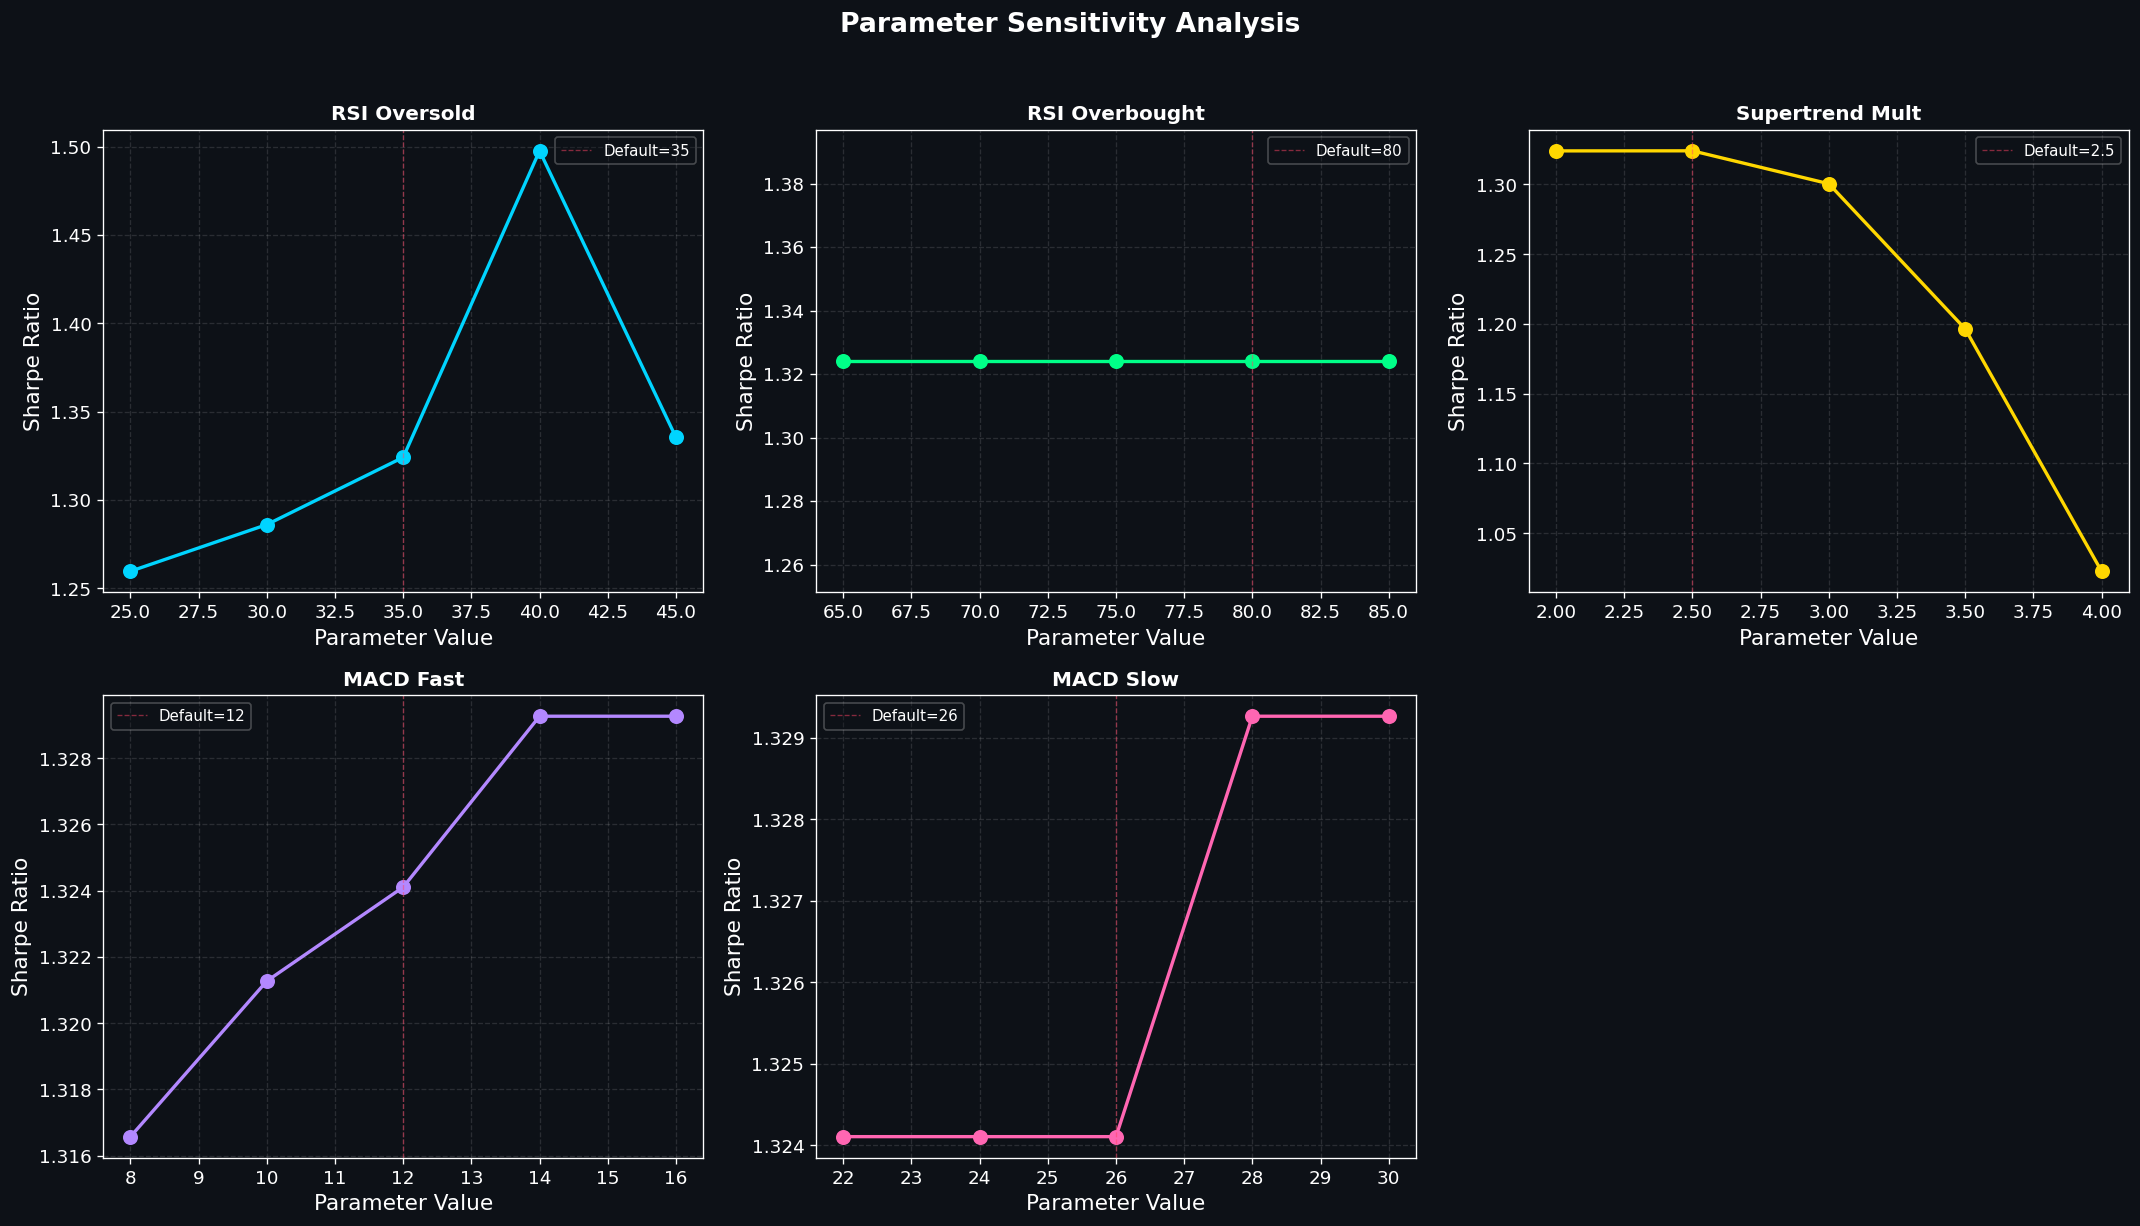

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
colors_sens = [C["cyan"], C["green"], C["yellow"], C["purple"], C["pink"]]

for idx, (name, df) in enumerate(sensitivity.items()):
    if idx >= len(axes):
        break
    ax = axes[idx]
    ax.plot(df["param"], df["sharpe"], "o-", color=colors_sens[idx], lw=2, markersize=8)
    ax.set_title(name, fontsize=12)
    ax.set_ylabel("Sharpe Ratio")
    ax.set_xlabel("Parameter Value")
    # Highlight default
    default_vals = {
        "RSI Oversold": P["rsi_oversold"], "RSI Overbought": P["rsi_overbought"],
        "Supertrend Mult": P["st_mult"], "MACD Fast": P["macd_fast"],
        "MACD Slow": P["macd_slow"],
    }
    if name in default_vals:
        ax.axvline(default_vals[name], color=C["red"], ls="--", alpha=0.5, lw=0.8,
                   label=f"Default={default_vals[name]}")
        ax.legend(fontsize=9, framealpha=0.3)

# Hide unused subplot
if len(sensitivity) < len(axes):
    for j in range(len(sensitivity), len(axes)):
        axes[j].set_visible(False)

fig.suptitle("Parameter Sensitivity Analysis", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
_save(fig, "12_sensitivity.png")
plt.show()

## Phase 5 - financial metrics to compare your strat

In [25]:
print("  FINAL RESULTS")

print(f"""
  PERFORMANCE:
    Starting Capital    : $ {INITIAL_CAPITAL:>12,.0f}
    Final Value (Strat) : $ {sm['End Value']:>12,.0f}
    Final Value (B&H)   : $ {bm_m['End Value']:>12,.0f}
    Ann. Return         : {sm['CAGR']*100:>10.2f}%  vs  {bm_m['CAGR']*100:.2f}% B&H
    Ann. Volatility     : {sm['Ann. Volatility']*100:>10.2f}%  vs  {bm_m['Ann. Volatility']*100:.2f}% B&H
    Sharpe Ratio        : {sm['Sharpe Ratio']:>10.3f}    vs  {bm_m['Sharpe Ratio']:.3f} B&H
    Max Drawdown        : {sm['Max Drawdown']*100:>10.2f}%  vs  {bm_m['Max Drawdown']*100:.2f}% B&H
    Calmar Ratio        : {sm['Calmar Ratio']:>10.3f}    vs  {bm_m['Calmar Ratio']:.3f} B&H

  OVERFITTING CHECK:
    Train Sharpe : {m_tr['Sharpe Ratio']:>7.3f}   |   Test Sharpe : {m_te['Sharpe Ratio']:>7.3f}
    Strategy is {'ROBUST' if m_te['Sharpe Ratio'] > 0 else 'WEAK'} in out-of-sample testing.
""")

  FINAL RESULTS

  PERFORMANCE:
    Starting Capital    : $    1,000,000
    Final Value (Strat) : $    8,372,503
    Final Value (B&H)   : $    6,320,127
    Ann. Return         :      39.91%  vs  33.83% B&H
    Ann. Volatility     :      24.74%  vs  27.01% B&H
    Sharpe Ratio        :      1.324    vs  1.069 B&H
    Max Drawdown        :     -28.04%  vs  -32.38% B&H
    Calmar Ratio        :      1.423    vs  1.045 B&H

  OVERFITTING CHECK:
    Train Sharpe :   1.308   |   Test Sharpe :   1.306
    Strategy is ROBUST in out-of-sample testing.



### Plot 13 — Final Performance Dashboard

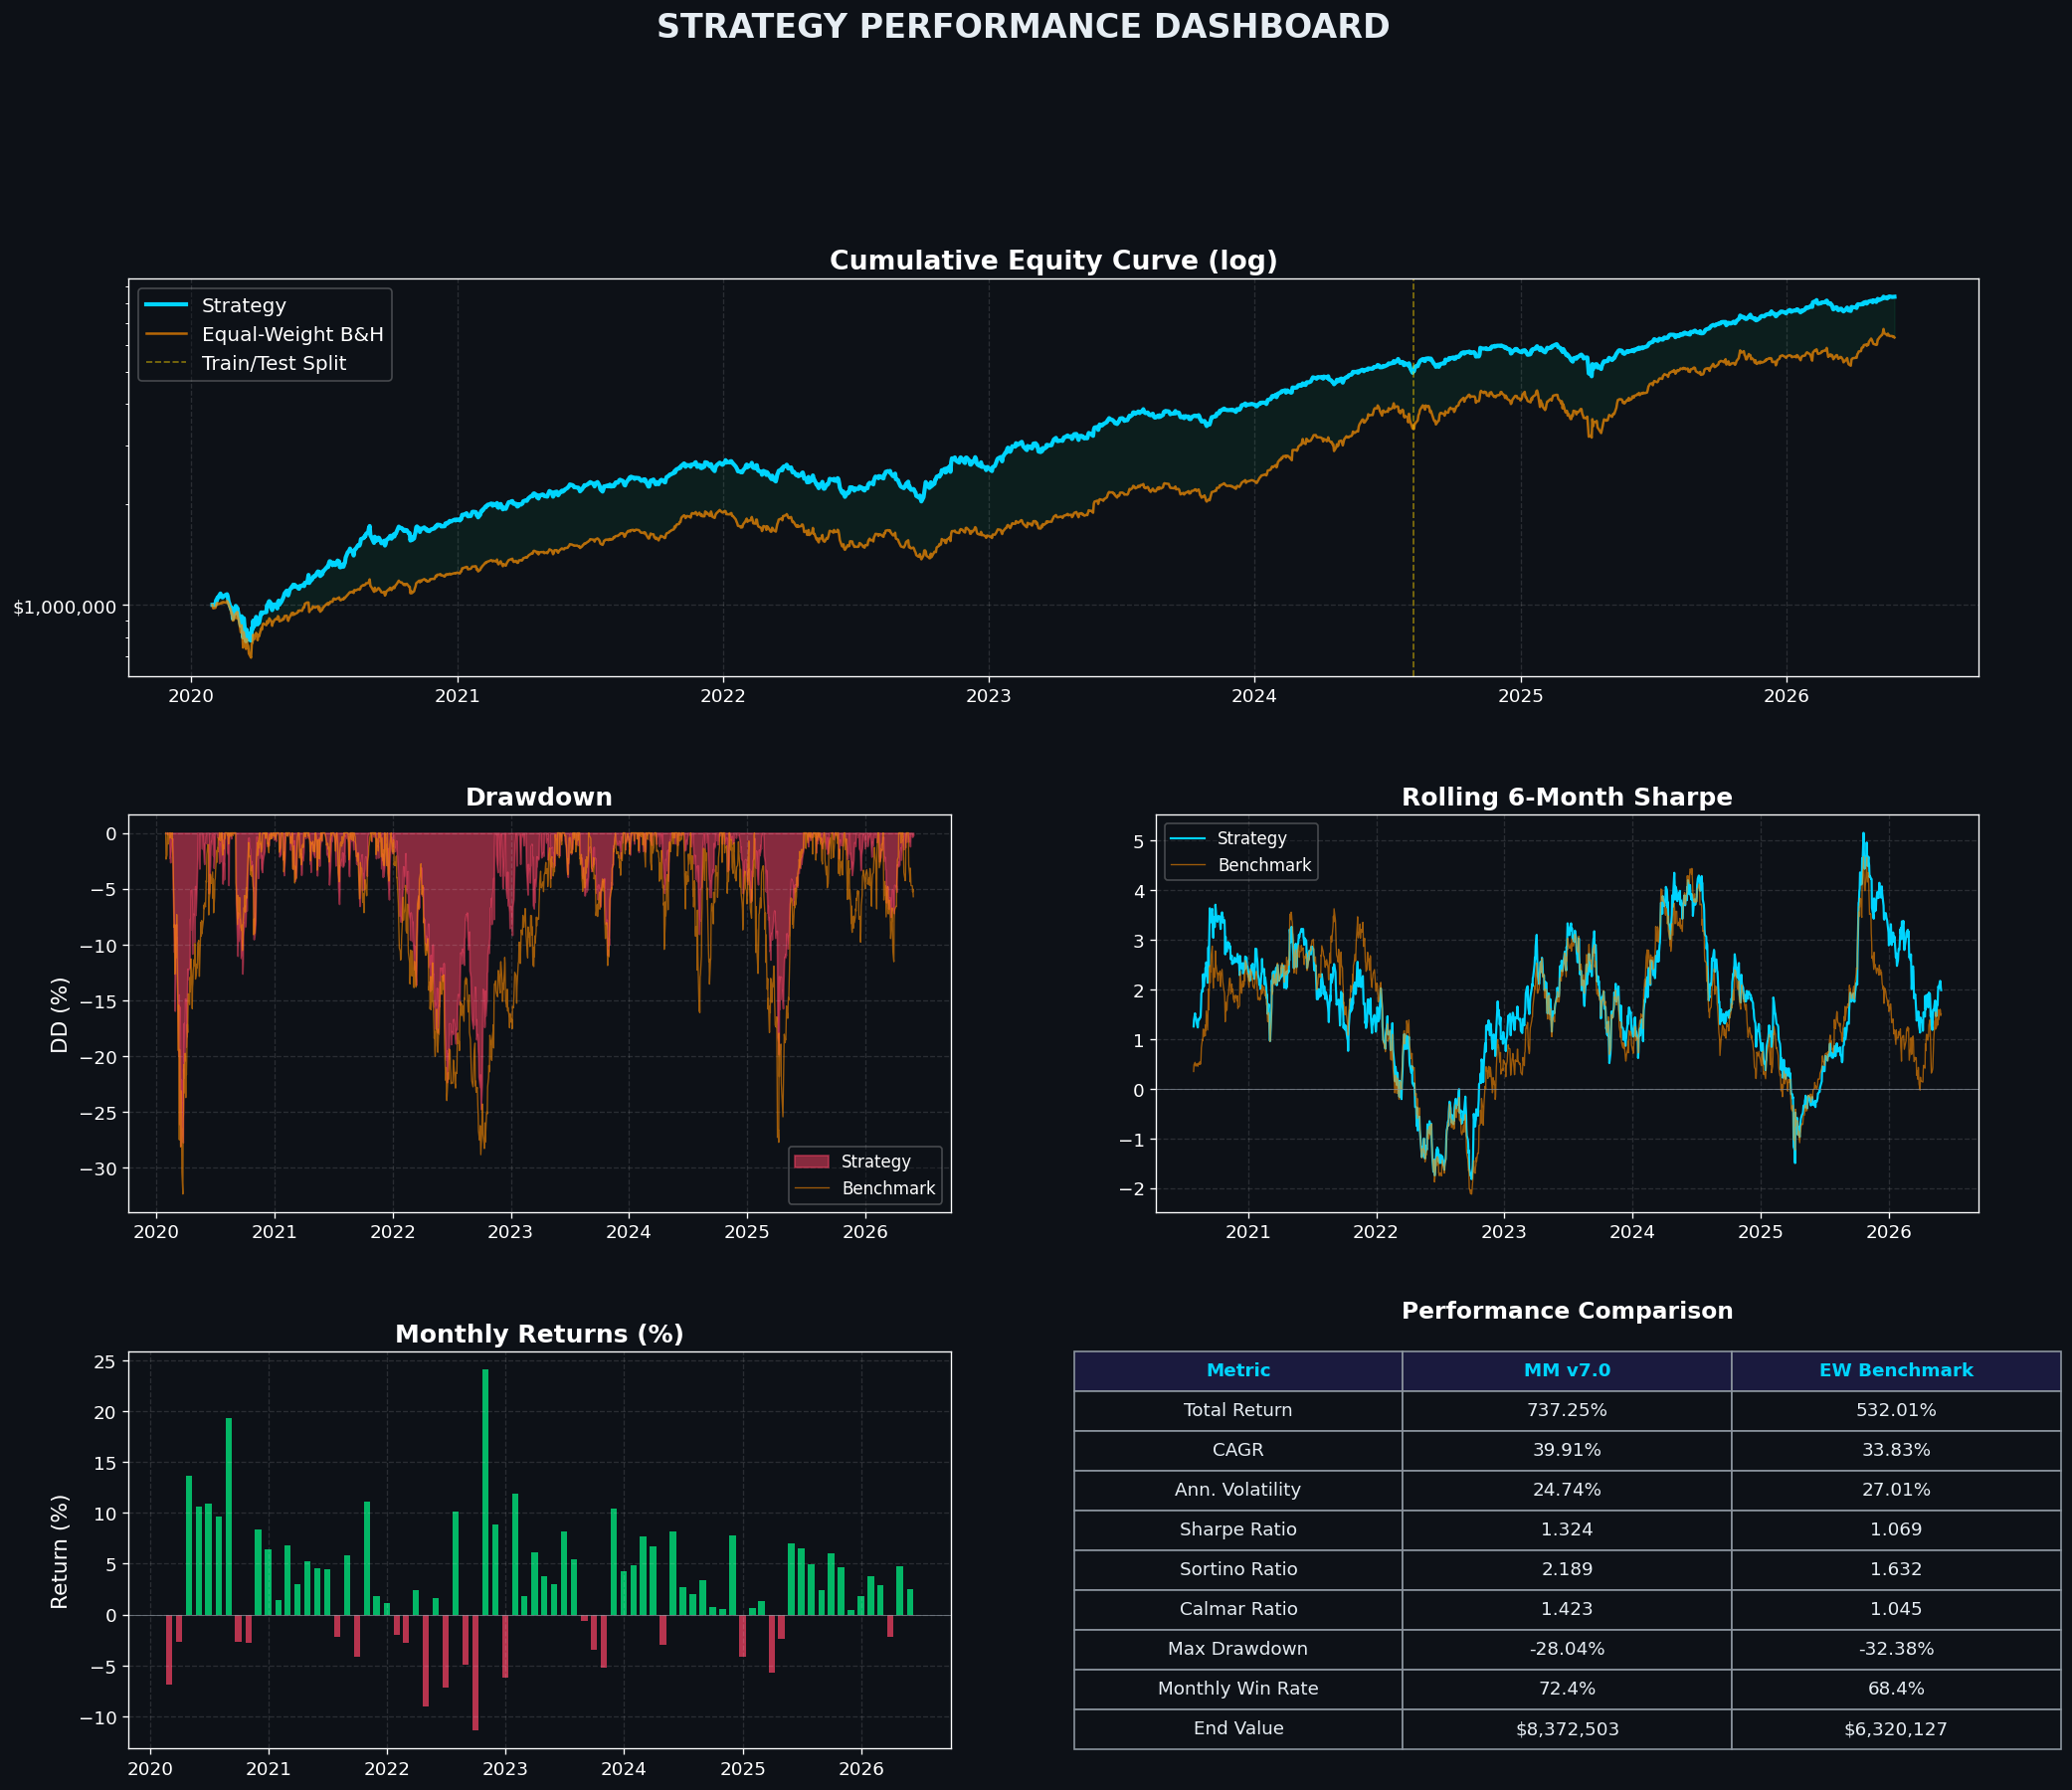

In [26]:
fig = plt.figure(figsize=(20, 16))
gs = gridspec.GridSpec(3, 2, hspace=0.35, wspace=0.25)

# Equity curve
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(pv.index, pv, color=C["cyan"], lw=2.5, label="Strategy")
ax1.plot(bm.index, bm, color=C["orange"], lw=1.5, alpha=0.7, label="Equal-Weight B&H")
ax1.set_yscale("log")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax1.axvline(split_date, color=C["yellow"], ls="--", lw=1, alpha=0.5, label="Train/Test Split")
ax1.set_title("Cumulative Equity Curve (log)", fontsize=16)
ax1.legend(fontsize=12, framealpha=0.3)
ax1.fill_between(pv.index, pv, bm, where=pv >= bm, color=C["green"], alpha=0.06)
ax1.fill_between(pv.index, pv, bm, where=pv < bm,  color=C["red"],   alpha=0.06)

# Drawdown
ax2 = fig.add_subplot(gs[1, 0])
ax2.fill_between(s_dd.index, s_dd * 100, 0, color=C["red"], alpha=0.5, label="Strategy")
ax2.plot(b_dd.index, b_dd * 100, color=C["orange"], lw=0.8, alpha=0.6, label="Benchmark")
ax2.set_title("Drawdown")
ax2.set_ylabel("DD (%)")
ax2.legend(fontsize=10, framealpha=0.3)

# Rolling Sharpe
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(rolling_sharpe.index, rolling_sharpe, color=C["cyan"], lw=1.3, label="Strategy")
ax3.plot(bench_rolling_sharpe.index, bench_rolling_sharpe, color=C["orange"],
         lw=0.8, alpha=0.6, label="Benchmark")
ax3.axhline(0, color=C["gray"], lw=0.4)
ax3.set_title("Rolling 6-Month Sharpe")
ax3.legend(fontsize=10, framealpha=0.3)

# Monthly returns bar
monthly_ret_strat = pv.resample("ME").last().pct_change().dropna() * 100
ax4 = fig.add_subplot(gs[2, 0])
colors_mr = [C["green"] if r > 0 else C["red"] for r in monthly_ret_strat]
ax4.bar(monthly_ret_strat.index, monthly_ret_strat, color=colors_mr, alpha=0.7, width=20)
ax4.axhline(0, color=C["gray"], lw=0.4)
ax4.set_title("Monthly Returns (%)")
ax4.set_ylabel("Return (%)")

# Metrics comparison table
ax5 = fig.add_subplot(gs[2, 1])
ax5.axis("off")
metric_names = ["Total Return", "CAGR", "Ann. Volatility", "Sharpe Ratio", 
                "Sortino Ratio", "Calmar Ratio", "Max Drawdown", "Monthly Win Rate", "End Value"]
table_data = []
for k in metric_names:
    sv, bv = sm[k], bm_m[k]
    if k == "End Value":
        table_data.append([k, f"${sv:,.0f}", f"${bv:,.0f}"])
    elif k in ["Total Return", "CAGR", "Ann. Volatility", "Max Drawdown"]:
        table_data.append([k, f"{sv*100:.2f}%", f"{bv*100:.2f}%"])
    elif k == "Monthly Win Rate":
        table_data.append([k, f"{sv*100:.1f}%", f"{bv*100:.1f}%"])
    else:
        table_data.append([k, f"{sv:.3f}", f"{bv:.3f}"])

tbl = ax5.table(cellText=table_data, colLabels=["Metric", sm["Label"], bm_m["Label"]],
                cellLoc="center", loc="center",
                colColours=[C["bg"]] * 3)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.2, 2)
for key, cell in tbl.get_celld().items():
    cell.set_edgecolor(C["gray"])
    cell.set_facecolor(C["bg"])
    cell.set_text_props(color=C["white"])
    if key[0] == 0:  # Header
        cell.set_facecolor("#1a1a3e")
        cell.set_text_props(fontweight="bold", color=C["cyan"])
ax5.set_title("Performance Comparison", fontsize=14, fontweight="bold", pad=20)

fig.suptitle("STRATEGY PERFORMANCE DASHBOARD", fontsize=20,
             fontweight="bold", color=C["white"], y=1.02)
_save(fig, "13_final_dashboard.png")
plt.show()

In [27]:
profit = sm["End Value"] - INITIAL_CAPITAL
bm_profit = bm_m["End Value"] - INITIAL_CAPITAL
alpha = profit - bm_profit

print(f"\n    Strategy Profit : ${profit:>12,.0f}")
print(f"    Benchmark Profit: ${bm_profit:>12,.0f}")
print(f"    Alpha Generated : ${alpha:>12,.0f}")
print(f"\n  {' Strategy OUTPERFORMS benchmark!' if profit > bm_profit else '🔴 Strategy underperforms benchmark.'}")
print("\n" + "═" * 72)


    Strategy Profit : $   7,372,503
    Benchmark Profit: $   5,320,127
    Alpha Generated : $   2,052,376

   Strategy OUTPERFORMS benchmark!

════════════════════════════════════════════════════════════════════════
